# Phase 3 — การวิเคราะห์ Backtest ของกลยุทธ์ Cross-Sectional Momentum บน SET

**วัตถุประสงค์:** ตรวจสอบและยืนยันว่า Momentum Signal ที่พัฒนาใน Phase 2 มีประสิทธิภาพเพียงพอสำหรับ Phase 4 (Portfolio & Risk Management)

**เกณฑ์ผ่าน Phase 3:**
- CAGR ของกลยุทธ์ > CAGR ของ SET TRI Benchmark
- Sharpe Ratio > 0.5
- มีการวิเคราะห์ Drawdown และ Sensitivity Analysis ครบถ้วน

**Notebook นี้เป็น Exit Gate ของ Phase 3 — ต้องผ่านทุกเกณฑ์ใน Section 8 จึงถือว่าสมบูรณ์**

In [1]:
# Setup — imports, paths, configuration
import asyncio
import logging
import os
import sys
import warnings
from pathlib import Path
from zoneinfo import ZoneInfo

_HERE = Path.cwd()
_PROJECT_ROOT = _HERE.parent if _HERE.name == 'notebooks' else _HERE
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, str(_PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
logging.basicConfig(level=logging.WARNING)

from csm.config.constants import (
    INDEX_SYMBOL,
    RISK_FREE_RATE_ANNUAL,
    TIMEZONE,
    TRANSACTION_COST_BPS,
)
from csm.config.settings import Settings
from csm.data.store import ParquetStore
from csm.features.pipeline import FeaturePipeline
from csm.research.backtest import BacktestConfig, MomentumBacktest
from csm.risk.drawdown import DrawdownAnalyzer
from csm.risk.metrics import PerformanceMetrics

QUICK_RUN: bool = False
QUICK_RUN_YEARS: int = 5
SHARPE_THRESHOLD: float = 0.5

settings = Settings()
_TZ = ZoneInfo(TIMEZONE)
sns.set_theme(style='darkgrid', palette='muted')

div_store = ParquetStore(settings.data_dir / 'raw' / 'dividends')
universe_store = ParquetStore(settings.data_dir / 'universe')

symbol_keys: list[str] = div_store.list_keys()
snapshot_keys: list[str] = sorted(
    k for k in universe_store.list_keys() if k.startswith('universe/')
)

print(f'Raw symbol parquets found : {len(symbol_keys)}')
print(f'Universe snapshots found  : {len(snapshot_keys)}')
print(f'Risk-free rate            : {RISK_FREE_RATE_ANNUAL:.1%}')
print(f'Transaction cost          : {TRANSACTION_COST_BPS} bps')
print(f'Benchmark                 : {INDEX_SYMBOL}')
print(f'QUICK_RUN                 : {QUICK_RUN}')

Raw symbol parquets found : 696
Universe snapshots found  : 207
Risk-free rate            : 2.0%
Transaction cost          : 15.0 bps
Benchmark                 : SET:SET
QUICK_RUN                 : False


## ส่วนที่ 1: ข้อมูลนำเข้า

โหลดข้อมูล OHLCV (Dividend-Adjusted) จาก `data/raw/dividends/` และ Universe Snapshots จาก `data/universe/`
สร้าง Feature Panel ผ่าน `FeaturePipeline` และเตรียม Price Matrix สำหรับ Backtest Engine

In [2]:
# Section 1 — Data loading and feature panel construction
feature_panel: pd.DataFrame = pd.DataFrame()
prices_wide: pd.DataFrame = pd.DataFrame()
benchmark_series: pd.Series | None = None
rebalance_dates: list[pd.Timestamp] = []

if not symbol_keys or not snapshot_keys:
    print('⚠ DATA NOT AVAILABLE — data/raw/dividends/ หรือ data/universe/ ว่างเปล่า')
    print('  รัน fetch_history.py และ build_universe.py ก่อนใช้ notebook นี้')
else:
    all_dates: list[pd.Timestamp] = [
        pd.Timestamp(k.split('/', 1)[-1], tz=_TZ) for k in snapshot_keys
    ]
    if QUICK_RUN:
        cutoff = all_dates[-1] - pd.DateOffset(years=QUICK_RUN_YEARS)
        rebalance_dates = [d for d in all_dates if d >= cutoff]
        print(f'QUICK_RUN: ใช้ {len(rebalance_dates)} rebalance dates')
    else:
        rebalance_dates = all_dates
    print(f'Rebalance dates: {len(rebalance_dates)} ({rebalance_dates[0].date()} → {rebalance_dates[-1].date()})')

    print('\nกำลังโหลด OHLCV...')
    prices_raw: dict[str, pd.DataFrame] = {}
    load_errors = 0
    for key in symbol_keys:
        try:
            df = div_store.load(key)
            if 'close' not in df.columns or len(df) == 0:
                continue
            if df.index.duplicated().any():
                df = df[~df.index.duplicated(keep='last')]
            if not df.index.is_monotonic_increasing:
                df = df.sort_index()
            prices_raw[key] = df
        except Exception:
            load_errors += 1
    print(f'  โหลดสำเร็จ: {len(prices_raw)} symbols (ข้าม: {load_errors})')

    symbol_sectors: dict[str, str] | None = None
    try:
        import settfex
        async def _fetch_sectors() -> dict[str, str]:
            resp = await settfex.get_stock_list()
            return {f'SET:{s.symbol}': getattr(s, 'sector', '') for s in resp.stocks if getattr(s, 'sector', '')}
        _loop = asyncio.new_event_loop()
        try:
            symbol_sectors = _loop.run_until_complete(_fetch_sectors())
            print(f'  Sector mapping: {len(symbol_sectors)} symbols')
        finally:
            _loop.close()
    except Exception as exc:
        print(f'  ⚠ Sector mapping ไม่พร้อมใช้งาน ({exc.__class__.__name__}) — ดำเนินการต่อโดยไม่มี sector_rel_strength')

    print('\nกำลังสร้าง Feature Panel...')
    fp = FeaturePipeline(div_store, universe_store, settings)
    feature_panel = fp.build(prices_raw, rebalance_dates, symbol_sectors=symbol_sectors)
    print(f'  Feature panel: {len(feature_panel)} rows, {len(feature_panel.columns)} features')
    if not feature_panel.empty:
        dates_in_panel = feature_panel.index.get_level_values('date').unique()
        print(f'  Dates: {len(dates_in_panel)} | Avg symbols/date: {len(feature_panel)/len(dates_in_panel):.0f}')

    stock_syms = [k for k in prices_raw if k != INDEX_SYMBOL]
    prices_wide = pd.DataFrame({k: prices_raw[k]['close'] for k in stock_syms})
    prices_wide.index = pd.to_datetime(prices_wide.index)
    prices_wide = prices_wide.sort_index()

    if INDEX_SYMBOL in prices_raw:
        benchmark_series = prices_raw[INDEX_SYMBOL]['close'].copy()
        benchmark_series.index = pd.to_datetime(benchmark_series.index)
        if benchmark_series.index.tz is not None:
            benchmark_series.index = benchmark_series.index.tz_convert(None)
        print(f'\nBenchmark ({INDEX_SYMBOL}): {len(benchmark_series)} periods')
    else:
        print(f'\n⚠ Benchmark {INDEX_SYMBOL} ไม่พบในข้อมูล')

    print(f'\n✅ Price matrix: {prices_wide.shape}')

Rebalance dates: 207 (2009-01-30 → 2026-03-31)

กำลังโหลด OHLCV...


  โหลดสำเร็จ: 694 symbols (ข้าม: 0)
  ⚠ Sector mapping ไม่พร้อมใช้งาน (RuntimeError) — ดำเนินการต่อโดยไม่มี sector_rel_strength

กำลังสร้าง Feature Panel...


/var/folders/5z/trsxbhl54q500q141xt6d99h0000gn/T/ipykernel_41827/2633231476.py:52: RuntimeWarning: coroutine '_fetch_sectors' was never awaited
  print(f'  ⚠ Sector mapping ไม่พร้อมใช้งาน ({exc.__class__.__name__}) — ดำเนินการต่อโดยไม่มี sector_rel_strength')


  Feature panel: 102642 rows, 6 features
  Dates: 207 | Avg symbols/date: 496



Benchmark (SET:SET): 5040 periods

✅ Price matrix: (9624, 693)


## ส่วนที่ 2: รัน Backtest

รัน `MomentumBacktest` ด้วย `BacktestConfig` ค่าเริ่มต้น:
- `formation_months = 12`, `skip_months = 1`, `top_quantile = 0.2`
- `weight_scheme = equal`, `transaction_cost_bps = 15`

In [3]:
# Section 2 — Run MomentumBacktest
backtest_result = None
equity_series: pd.Series | None = None

if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 2')
else:
    config = BacktestConfig(
        formation_months=12,
        skip_months=1,
        top_quantile=0.2,
        weight_scheme='equal',
        transaction_cost_bps=TRANSACTION_COST_BPS,
    )
    store_bt = ParquetStore(settings.data_dir / 'raw' / 'dividends')
    backtest = MomentumBacktest(store_bt)
    print('กำลังรัน Backtest...')
    backtest_result = backtest.run(feature_panel, prices_wide, config)
    print('✅ Backtest เสร็จสมบูรณ์')

    equity_series = pd.Series(
        {pd.Timestamp(k): v for k, v in backtest_result.equity_curve.items()}
    ).sort_index()

    metrics = backtest_result.metrics
    pct_keys = {'cagr', 'max_drawdown', 'win_rate', 'avg_monthly_return', 'volatility', 'alpha'}
    rows = []
    labels = {
        'cagr': 'CAGR', 'sharpe': 'Sharpe Ratio', 'sortino': 'Sortino Ratio',
        'calmar': 'Calmar Ratio', 'max_drawdown': 'Max Drawdown', 'win_rate': 'Win Rate',
        'avg_monthly_return': 'Avg Monthly Return', 'volatility': 'Annual Volatility',
        'alpha': 'Alpha', 'beta': 'Beta', 'information_ratio': 'Information Ratio',
    }
    for k, label in labels.items():
        if k in metrics:
            v = metrics[k]
            rows.append({'Metric': label, 'Value': f'{v:.2%}' if k in pct_keys else f'{v:.4f}'})
    print('\n' + '=' * 40 + '\n  Performance Metrics Summary\n' + '=' * 40)
    print(pd.DataFrame(rows).set_index('Metric').to_string())
    print('=' * 40)

กำลังรัน Backtest...


✅ Backtest เสร็จสมบูรณ์

  Performance Metrics Summary
                      Value
Metric                     
CAGR                 12.45%
Sharpe Ratio         0.6349
Sortino Ratio        0.9638
Calmar Ratio         0.3004
Max Drawdown        -41.45%
Win Rate             60.00%
Avg Monthly Return    1.12%
Annual Volatility    17.95%


## ส่วนที่ 3: เส้น Equity Curve

เปรียบเทียบ Equity Curve ของกลยุทธ์ Momentum กับ SET TRI Benchmark — NAV เริ่มที่ 100
พื้นที่สีแดงคือช่วง Drawdown (NAV ต่ำกว่า Peak)

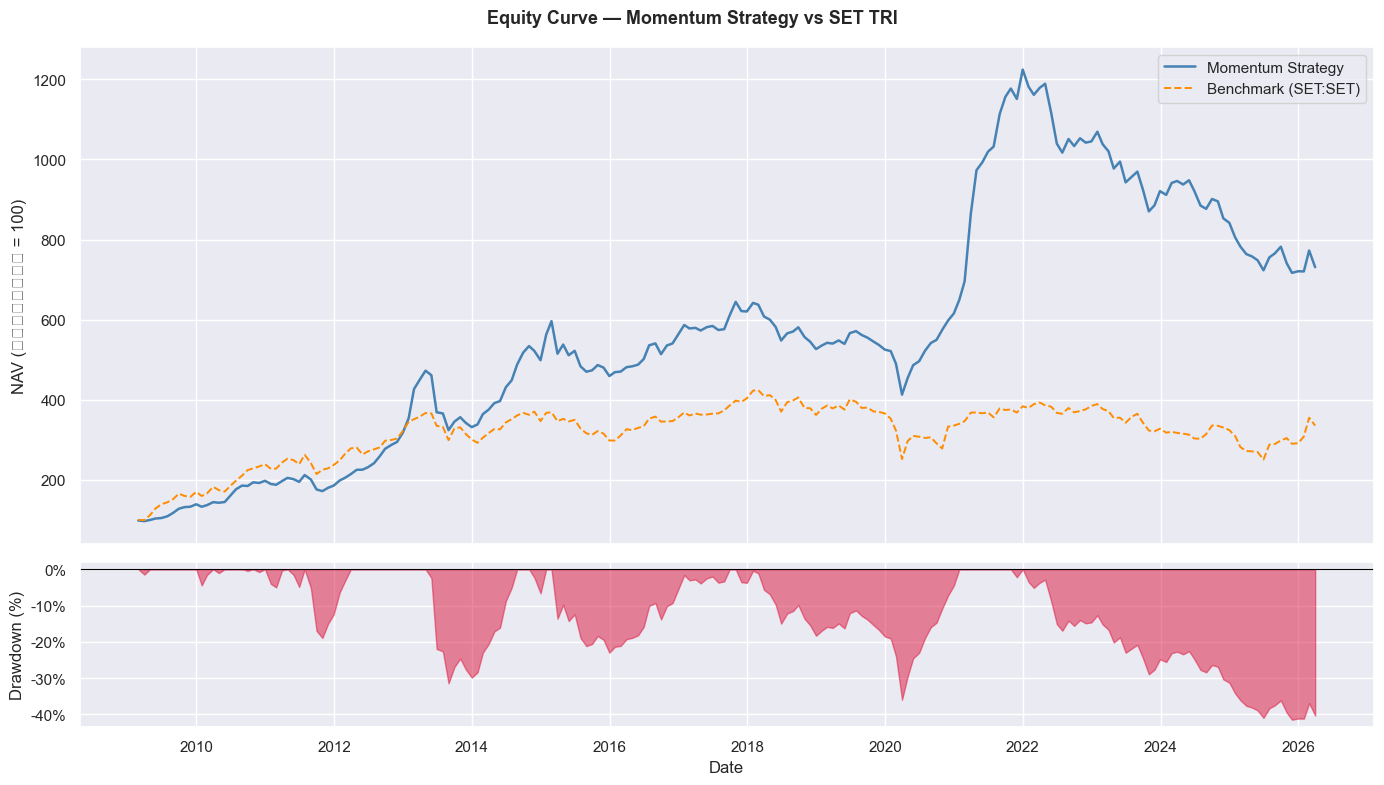

In [4]:
# Section 3 — Equity Curve vs Benchmark
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 3')
else:
    da = DrawdownAnalyzer()
    underwater = da.underwater_curve(equity_series)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 1]}, sharex=True
    )
    fig.suptitle('Equity Curve — Momentum Strategy vs SET TRI', fontsize=13, fontweight='bold')

    ax1.plot(equity_series.index, equity_series.values, color='steelblue', linewidth=1.8,
             label='Momentum Strategy')
    if benchmark_series is not None:
        bm_al = benchmark_series.reindex(equity_series.index, method='ffill')
        bm_nav = bm_al / bm_al.iloc[0] * 100.0
        ax1.plot(bm_nav.index, bm_nav.values, color='darkorange', linewidth=1.4,
                 linestyle='--', label=f'Benchmark ({INDEX_SYMBOL})')
    ax1.set_ylabel('NAV (เริ่มต้น = 100)')
    ax1.legend()
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

    ax2.fill_between(underwater.index, underwater.values * 100, 0, color='crimson', alpha=0.5)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_xlabel('Date')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

## ส่วนที่ 4: ผลตอบแทนรายปี

เปรียบเทียบผลตอบแทนของกลยุทธ์และ Benchmark แยกตามปี
พร้อมตารางแสดง Excess Return ในแต่ละปี

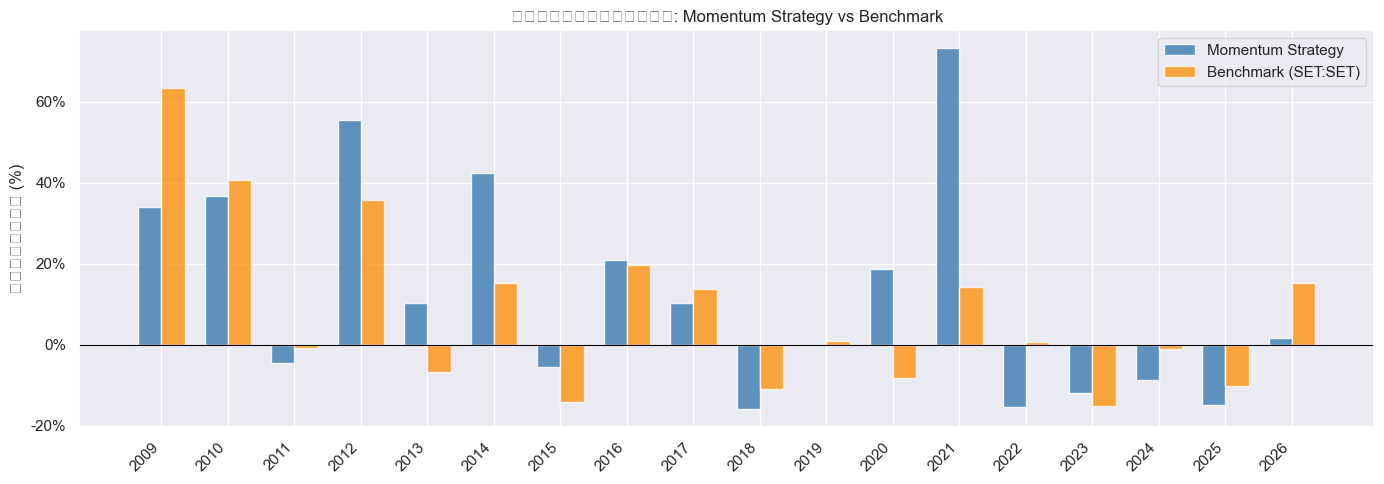


ตารางผลตอบแทนรายปี:
     Strategy Benchmark Excess Return
2009   34.01%    63.25%       -29.23%
2010   36.77%    40.60%        -3.83%
2011   -4.35%    -0.72%        -3.63%
2012   55.32%    35.76%        19.57%
2013   10.34%    -6.70%        17.04%
2014   42.39%    15.32%        27.07%
2015   -5.57%   -14.00%         8.43%
2016   20.97%    19.79%         1.17%
2017   10.27%    13.66%        -3.39%
2018  -15.77%   -10.82%        -4.95%
2019   -0.01%     1.02%        -1.03%
2020   18.64%    -8.26%        26.90%
2021   73.09%    14.37%        58.72%
2022  -15.20%     0.67%       -15.86%
2023  -11.90%   -15.15%         3.25%
2024   -8.65%    -1.10%        -7.54%
2025  -14.93%   -10.04%        -4.89%
2026    1.80%    15.15%       -13.36%


In [5]:
# Section 4 — Annual Returns
if backtest_result is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 4')
else:
    strat_ann = pd.Series(backtest_result.annual_returns_dict(), name='Strategy')
    strat_ann.index = strat_ann.index.astype(str)

    bm_ann: pd.Series | None = None
    if benchmark_series is not None:
        bm_ts = benchmark_series.copy()
        bm_ts.index = pd.to_datetime(bm_ts.index)
        bm_raw = bm_ts.resample('YE').last().pct_change().dropna()
        bm_ann = bm_raw.copy()
        bm_ann.index = bm_ann.index.year.astype(str)
        bm_ann.name = 'Benchmark'

    fig, ax = plt.subplots(figsize=(14, 5))
    x = list(range(len(strat_ann)))
    bw = 0.35
    ax.bar([xi - bw/2 for xi in x], strat_ann.values * 100, width=bw,
           label='Momentum Strategy', color='steelblue', alpha=0.85)
    if bm_ann is not None:
        aln_bm = bm_ann.reindex(strat_ann.index).fillna(0)
        ax.bar([xi + bw/2 for xi in x], aln_bm.values * 100, width=bw,
               label=f'Benchmark ({INDEX_SYMBOL})', color='darkorange', alpha=0.75)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(strat_ann.index.tolist(), rotation=45, ha='right')
    ax.set_ylabel('ผลตอบแทน (%)')
    ax.set_title('ผลตอบแทนรายปี: Momentum Strategy vs Benchmark')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    if bm_ann is not None:
        cdf = pd.DataFrame({'Strategy': strat_ann, 'Benchmark': bm_ann.reindex(strat_ann.index)})
        cdf['Excess Return'] = cdf['Strategy'] - cdf['Benchmark']
        for col in cdf.columns:
            cdf[col] = cdf[col].map(lambda v: f'{v:.2%}' if pd.notna(v) else 'N/A')
        print('\nตารางผลตอบแทนรายปี:')
        print(cdf.to_string())
    else:
        print(strat_ann.map(lambda v: f'{v:.2%}').to_string())

## ส่วนที่ 5: Rolling Sharpe Ratio

Rolling Sharpe Ratio 12 เดือน — ช่วงที่เส้นอยู่ต่ำกว่าศูนย์คือช่วงที่กลยุทธ์ให้ผลตอบแทนต่ำกว่า Risk-Free Rate

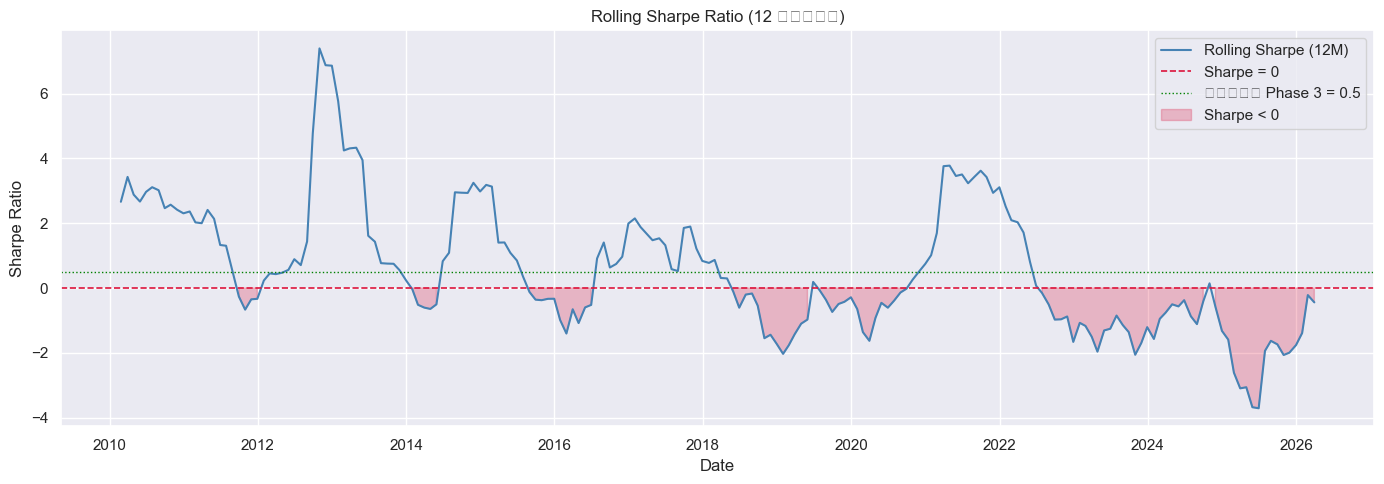

ช่วงที่ Rolling Sharpe < 0: 47.4% ของเวลาทั้งหมด


In [6]:
# Section 5 — Rolling Sharpe Ratio
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 5')
else:
    monthly_rets = equity_series.pct_change().dropna()

    def _rolling_sharpe(returns: pd.Series, window: int = 12) -> pd.Series:
        rf_m = RISK_FREE_RATE_ANNUAL / 12.0
        excess = returns - rf_m
        roll_std = returns.rolling(window).std(ddof=0)
        return (excess.rolling(window).mean() / roll_std) * (12 ** 0.5)

    rs = _rolling_sharpe(monthly_rets)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(rs.index, rs.values, color='steelblue', linewidth=1.5, label='Rolling Sharpe (12M)')
    ax.axhline(0, color='crimson', linewidth=1.2, linestyle='--', label='Sharpe = 0')
    ax.axhline(SHARPE_THRESHOLD, color='green', linewidth=1.0, linestyle=':',
               label=f'เกณฑ์ Phase 3 = {SHARPE_THRESHOLD}')
    ax.fill_between(rs.index, rs.values, 0, where=(rs.values < 0),
                    color='crimson', alpha=0.25, label='Sharpe < 0')
    ax.set_title('Rolling Sharpe Ratio (12 เดือน)')
    ax.set_ylabel('Sharpe Ratio')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.show()

    neg_pct = (rs.dropna() < 0).mean()
    print(f'ช่วงที่ Rolling Sharpe < 0: {neg_pct:.1%} ของเวลาทั้งหมด')

## ส่วนที่ 6: การวิเคราะห์ Drawdown

Underwater Curve และตาราง Drawdown Episodes (ไม่รวม Open Episode ที่ยังไม่ฟื้นตัว)
เรียงตาม Depth จากลึกเป็นตื้นตั้น

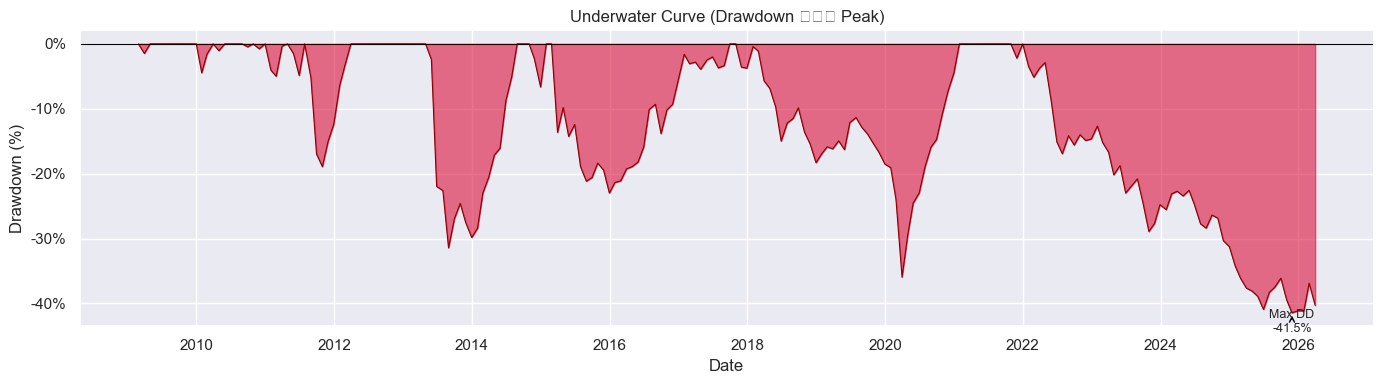

Drawdown Episodes (13 รายการ):
     Start     Trough   Recovery   Depth  Duration (days)  recovery_months
2010-09-30 2010-09-30 2010-10-29  -0.46%               29              1.0
2010-11-30 2010-11-30 2010-12-31  -0.76%               31              1.0
2010-04-30 2010-04-30 2010-05-31  -1.05%               31              1.0
2009-03-31 2009-03-31 2009-04-30  -1.48%               30              1.0
2011-08-31 2011-10-31 2012-03-30 -18.93%              212              7.0
2021-11-30 2021-11-30 2021-12-31  -2.21%               31              1.0
2015-03-31 2015-12-31 2017-09-29 -22.99%              913             29.9
2013-05-31 2013-08-30 2014-08-29 -31.44%              455             14.9
2017-11-30 2020-03-31 2021-01-29 -35.95%             1156             37.9
2010-01-29 2010-01-29 2010-03-31  -4.46%               61              2.0
2011-05-31 2011-06-30 2011-07-29  -4.87%               59              1.9
2011-01-31 2011-02-28 2011-04-29  -5.00%               88            

In [7]:
# Section 6 — Drawdown Analysis
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 6')
else:
    da = DrawdownAnalyzer()
    underwater = da.underwater_curve(equity_series)
    episodes = da.recovery_periods(equity_series)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(underwater.index, underwater.values * 100, 0, color='crimson', alpha=0.6)
    ax.plot(underwater.index, underwater.values * 100, color='darkred', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.8)

    max_dd_date = underwater.idxmin()
    max_dd_pct = float(underwater.min() * 100)
    ax.annotate(
        f'Max DD\n{max_dd_pct:.1f}%',
        xy=(max_dd_date, max_dd_pct),
        xytext=(max_dd_date, max_dd_pct - 3),
        arrowprops={'arrowstyle': '->', 'color': 'black'},
        fontsize=9, ha='center',
    )
    ax.set_title('Underwater Curve (Drawdown จาก Peak)')
    ax.set_ylabel('Drawdown (%)')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.tight_layout()
    plt.show()

    if episodes.empty:
        print('✅ ไม่พบ Drawdown Episodes ที่สมบูรณ์')
    else:
        ep = episodes.copy()
        ep['depth'] = ep['depth'].map(lambda v: f'{v:.2%}')
        ep['start'] = ep['start'].dt.strftime('%Y-%m-%d')
        ep['trough'] = ep['trough'].dt.strftime('%Y-%m-%d')
        ep['recovery'] = ep['recovery'].dt.strftime('%Y-%m-%d')
        ep = ep.rename(columns={
            'start': 'Start', 'trough': 'Trough', 'recovery': 'Recovery',
            'depth': 'Depth', 'duration_days': 'Duration (days)'
        }).sort_values('Depth')
        print(f'Drawdown Episodes ({len(ep)} รายการ):')
        print(ep.to_string(index=False))

## ส่วนที่ 7: Sensitivity Analysis

| พารามิเตอร์ | ค่าที่ทดสอบ |
|---|---|
| `top_quantile` | 0.1, 0.2, 0.3 |
| `formation_months` | 3, 6, 12 |

Heatmap แสดง Sharpe Ratio ของแต่ละ Combination — ถ้ากลยุทธ์แข็งแกร่ง ค่า Sharpe ควรเป็นบวกในส่วนใหญ่ของ Grid

กำลังรัน Sensitivity Grid (3×3 = 9 combinations)...


  tq=0.1, fm=3 → Sharpe=0.635


  tq=0.1, fm=6 → Sharpe=0.635


  tq=0.1, fm=12 → Sharpe=0.635


  tq=0.2, fm=3 → Sharpe=0.635


  tq=0.2, fm=6 → Sharpe=0.635


  tq=0.2, fm=12 → Sharpe=0.635


  tq=0.3, fm=3 → Sharpe=0.635


  tq=0.3, fm=6 → Sharpe=0.635


  tq=0.3, fm=12 → Sharpe=0.635


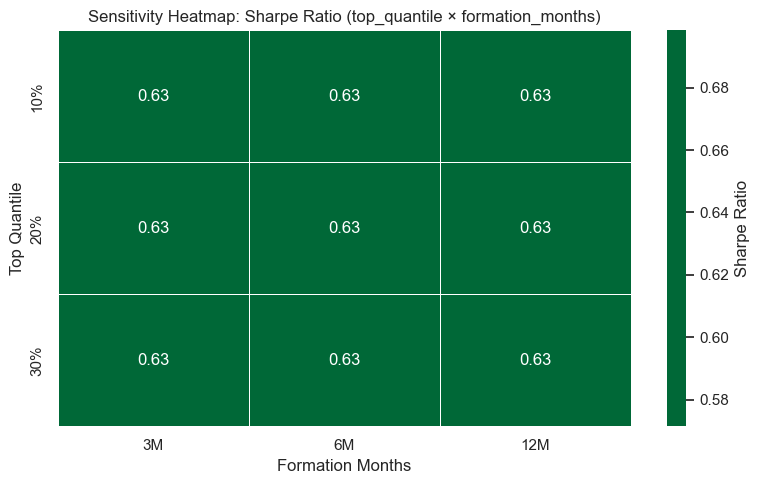


Sharpe > 0 ใน 9/9 combinations (100%)


In [8]:
# Section 7 — Sensitivity Analysis
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 7')
else:
    top_quantiles = [0.1, 0.2, 0.3]
    fm_list = [3, 6, 12]
    store_s = ParquetStore(settings.data_dir / 'raw' / 'dividends')
    grid: dict[str, dict[str, float]] = {}
    print('กำลังรัน Sensitivity Grid (3×3 = 9 combinations)...')
    for tq in top_quantiles:
        rk = f'tq={tq}'
        grid[rk] = {}
        for fm in fm_list:
            ck = f'fm={fm}'
            try:
                cfg = BacktestConfig(formation_months=fm, skip_months=1,
                                     top_quantile=tq, weight_scheme='equal',
                                     transaction_cost_bps=TRANSACTION_COST_BPS)
                res = MomentumBacktest(store_s).run(feature_panel, prices_wide, cfg)
                sv = res.metrics.get('sharpe', float('nan'))
                grid[rk][ck] = sv
                print(f'  tq={tq}, fm={fm} → Sharpe={sv:.3f}')
            except Exception as exc:
                grid[rk][ck] = float('nan')
                print(f'  ⚠ tq={tq}, fm={fm} → Error: {exc}')

    hmap = pd.DataFrame(grid).T
    hmap.index = [f'{float(s.split("=")[1]):.0%}' for s in hmap.index]
    hmap.columns = [f'{s.split("=")[1]}M' for s in hmap.columns]
    hmap.index.name = 'Top Quantile'
    hmap.columns.name = 'Formation Months'

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(hmap.astype(float), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Sharpe Ratio'})
    ax.set_title('Sensitivity Heatmap: Sharpe Ratio (top_quantile × formation_months)')
    plt.tight_layout()
    plt.show()

    n_pos = int((hmap.astype(float) > 0).sum().sum())
    print(f'\nSharpe > 0 ใน {n_pos}/{hmap.size} combinations ({n_pos/hmap.size:.0%})')

## ส่วนที่ 10: Rolling Return Analysis (Rolling CAGR)

วิเคราะห์ Rolling CAGR แบบ 12, 24 และ 36 เดือน เพื่อตรวจสอบว่ากลยุทธ์มีความสม่ำเสมอในระยะยาว
หรือมีช่วงที่ผลตอบแทน "ล้าลง" (Momentum Fatigue)

- เส้นแดง = ช่วงที่ Rolling CAGR ติดลบ
- เส้นประเทา = Risk-Free Rate

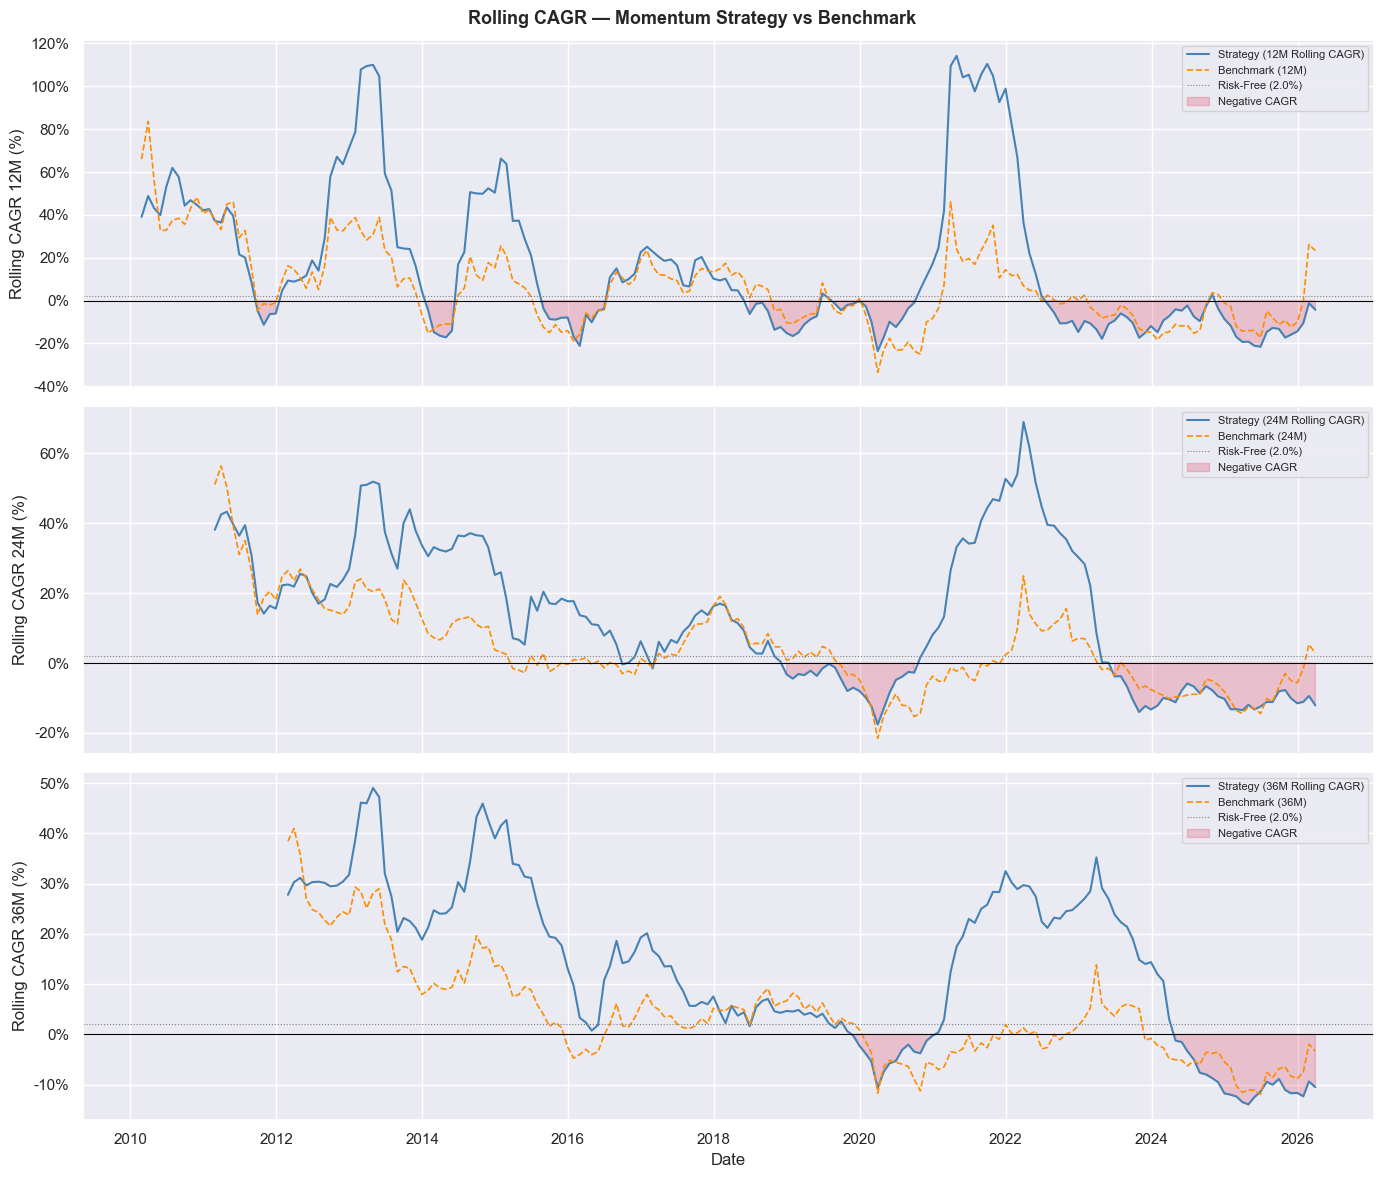


── สรุป Rolling CAGR ──
Window       Mean     Neg%  Below RF%
------------------------------------
12M        16.51%    46.4%      47.9%
24M        13.93%    31.9%      35.7%
36M        13.82%    22.4%      25.9%


In [9]:
# Section 10 — Rolling Return Analysis (Rolling CAGR)
if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 10')
else:
    windows = [12, 24, 36]
    rolling_cagrs: dict[str, pd.Series] = {}
    bm_rolling_cagrs: dict[str, pd.Series] = {}

    for w in windows:
        rolling_cagrs[f'{w}M'] = PerformanceMetrics.rolling_cagr(equity_series, w)

    if benchmark_series is not None:
        bm_nav_rc = benchmark_series.reindex(equity_series.index, method='ffill')
        bm_nav_rc = bm_nav_rc / bm_nav_rc.iloc[0] * 100.0
        for w in windows:
            bm_rolling_cagrs[f'{w}M'] = PerformanceMetrics.rolling_cagr(bm_nav_rc, w)

    fig, axes = plt.subplots(len(windows), 1, figsize=(14, 4 * len(windows)), sharex=True)
    fig.suptitle('Rolling CAGR — Momentum Strategy vs Benchmark', fontsize=13, fontweight='bold')

    for ax, w in zip(axes, windows):
        key = f'{w}M'
        strat = rolling_cagrs[key].dropna()
        ax.plot(strat.index, strat.values * 100, color='steelblue', linewidth=1.5,
                label=f'Strategy ({key} Rolling CAGR)')
        if key in bm_rolling_cagrs:
            bm_rc = bm_rolling_cagrs[key].dropna()
            ax.plot(bm_rc.index, bm_rc.values * 100, color='darkorange', linewidth=1.2,
                    linestyle='--', label=f'Benchmark ({key})')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axhline(RISK_FREE_RATE_ANNUAL * 100, color='gray', linewidth=0.8,
                   linestyle=':', label=f'Risk-Free ({RISK_FREE_RATE_ANNUAL:.1%})')
        ax.fill_between(strat.index, strat.values * 100, 0,
                        where=(strat.values < 0), color='crimson', alpha=0.2, label='Negative CAGR')
        ax.set_ylabel(f'Rolling CAGR {key} (%)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.legend(fontsize=8)

    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

    print('\n── สรุป Rolling CAGR ──')
    print(f'{"Window":<8} {"Mean":>8} {"Neg%":>8} {"Below RF%":>10}')
    print('-' * 36)
    for w in windows:
        key = f'{w}M'
        s = rolling_cagrs[key].dropna()
        neg_pct = float((s < 0).mean())
        below_rf = float((s < RISK_FREE_RATE_ANNUAL).mean())
        print(f'{key:<8} {s.mean():>8.2%} {neg_pct:>8.1%} {below_rf:>10.1%}')

## ส่วนที่ 11: Transaction Cost Sensitivity

ทดสอบผลกระทบของ Transaction Cost ในระดับ 15, 20, และ 25 bps ต่อ CAGR, Sharpe, Max Drawdown และ Calmar Ratio
เพื่อตรวจสอบว่ากลยุทธ์ยังทำกำไรได้เมื่อ Cost สูงขึ้น

กำลังรัน Transaction Cost Sensitivity (3 levels)...


  15 bps → CAGR=12.45%, Sharpe=0.6349, MaxDD=-41.45%


  20 bps → CAGR=12.32%, Sharpe=0.6284, MaxDD=-41.76%


  25 bps → CAGR=12.19%, Sharpe=0.6218, MaxDD=-42.06%

── ตาราง Transaction Cost Sensitivity ──
              CAGR  Sharpe Max Drawdown  Calmar Volatility
Cost (bps)                                                
15          12.45%  0.6349      -41.45%  0.3004     17.95%
20          12.32%  0.6284      -41.76%  0.2951     17.95%
25          12.19%  0.6218      -42.06%  0.2899     17.95%


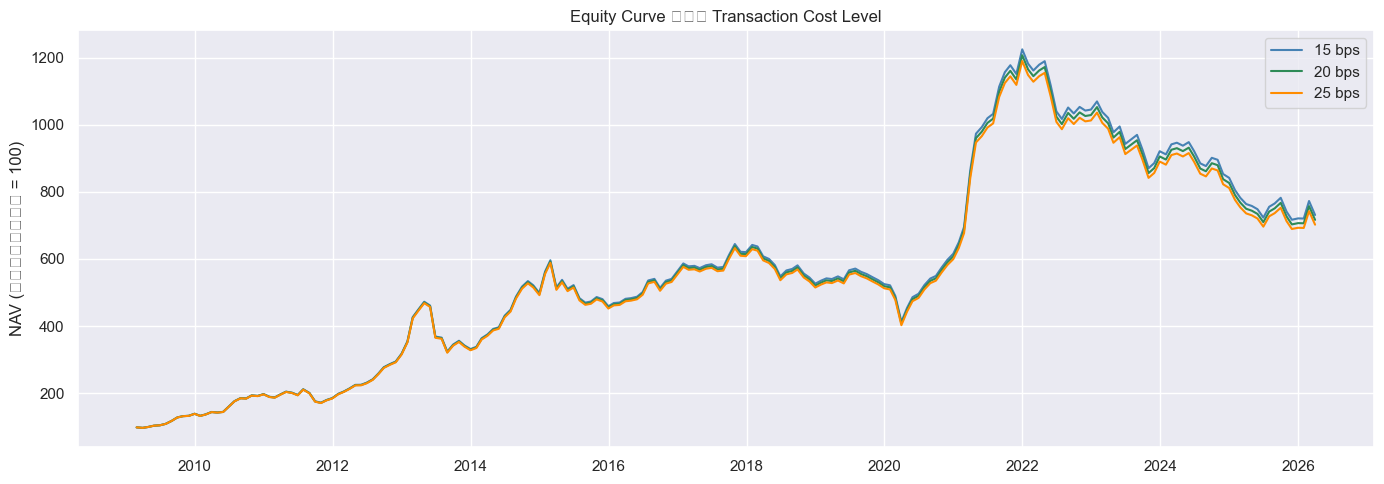

In [10]:
# Section 11 — Transaction Cost Sensitivity
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 11')
else:
    _cost_levels = [15, 20, 25]
    _cost_rows: list[dict] = []
    _cost_equities: list[tuple[int, pd.Series]] = []

    print('กำลังรัน Transaction Cost Sensitivity (3 levels)...')
    for _bps in _cost_levels:
        try:
            _cfg = BacktestConfig(
                formation_months=12, skip_months=1, top_quantile=0.2,
                weight_scheme='equal', transaction_cost_bps=float(_bps),
            )
            _res = MomentumBacktest(
                ParquetStore(settings.data_dir / 'raw' / 'dividends')
            ).run(feature_panel, prices_wide, _cfg)
            _m = _res.metrics
            _eq = pd.Series(
                {pd.Timestamp(k): v for k, v in _res.equity_curve.items()}
            ).sort_index()
            _cost_equities.append((_bps, _eq))
            _cost_rows.append({
                'Cost (bps)': _bps,
                'CAGR': f"{_m.get('cagr', 0):.2%}",
                'Sharpe': f"{_m.get('sharpe', 0):.4f}",
                'Max Drawdown': f"{_m.get('max_drawdown', 0):.2%}",
                'Calmar': f"{_m.get('calmar', 0):.4f}",
                'Volatility': f"{_m.get('volatility', 0):.2%}",
            })
            print(f'  {_bps} bps → CAGR={_m.get("cagr",0):.2%}, '
                  f'Sharpe={_m.get("sharpe",0):.4f}, MaxDD={_m.get("max_drawdown",0):.2%}')
        except Exception as _exc:
            print(f'  ⚠ {_bps} bps → Error: {_exc}')

    print('\n── ตาราง Transaction Cost Sensitivity ──')
    _cost_df = pd.DataFrame(_cost_rows).set_index('Cost (bps)')
    print(_cost_df.to_string())

    _colors_cost = ['steelblue', 'seagreen', 'darkorange']
    fig, ax = plt.subplots(figsize=(14, 5))
    for _i, (_bps, _eq) in enumerate(_cost_equities):
        ax.plot(_eq.index, _eq.values, color=_colors_cost[_i % len(_colors_cost)],
                linewidth=1.5, label=f'{_bps} bps')
    ax.set_title('Equity Curve ตาม Transaction Cost Level')
    ax.set_ylabel('NAV (เริ่มต้น = 100)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

## ส่วนที่ 12: Turnover Analysis

วิเคราะห์การกระจายของ Monthly Turnover — ค่าสูงแสดงถึงค่าใช้จ่ายซ่อนเร้นที่สูง
และความเสี่ยงจาก Slippage ในตลาดที่มี Liquidity ต่ำ

── สถิติ Monthly Turnover ──
count    20600.00%
mean        19.63%
std          4.92%
min         10.00%
10%         14.00%
25%         16.00%
50%         19.00%
75%         22.00%
90%         25.00%
max         50.00%

Annualised Turnover (mean × 12): 235.57%


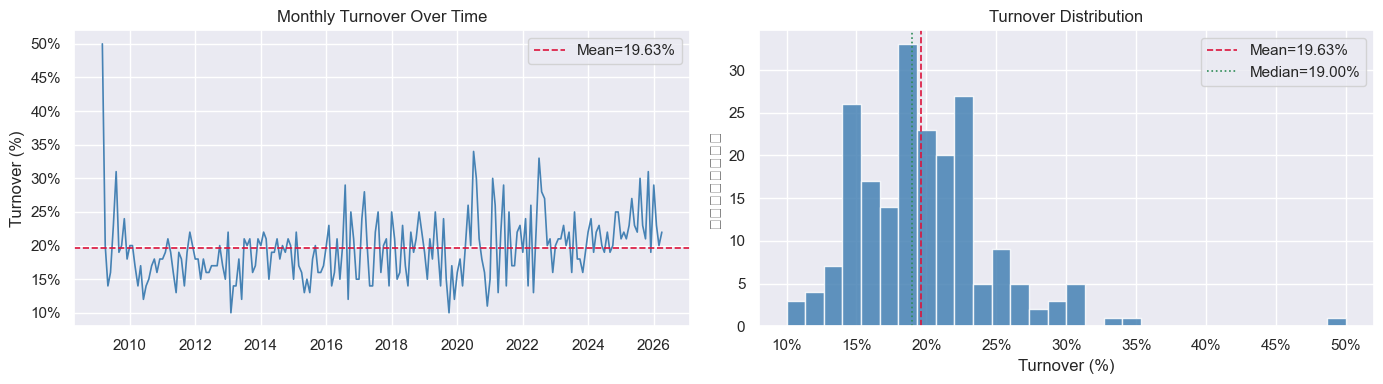


รอบที่มี Turnover > P75 (22.00%): 43 รอบ (20.9% ของทั้งหมด)


In [11]:
# Section 12 — Turnover Analysis
if backtest_result is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 12')
else:
    _to_series = pd.Series(backtest_result.turnover)
    _to_series.index = pd.to_datetime(_to_series.index)
    _to_series = _to_series.sort_index()

    print('── สถิติ Monthly Turnover ──')
    _to_stats = _to_series.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    print(_to_stats.map(lambda v: f'{v:.2%}').to_string())
    print(f'\nAnnualised Turnover (mean × 12): {_to_series.mean() * 12:.2%}')

    fig, _axes_to = plt.subplots(1, 2, figsize=(14, 4))

    _axes_to[0].plot(_to_series.index, _to_series.values * 100,
                     color='steelblue', linewidth=1.2)
    _axes_to[0].axhline(float(_to_series.mean() * 100), color='crimson', linestyle='--',
                        linewidth=1.2, label=f'Mean={_to_series.mean():.2%}')
    _axes_to[0].set_title('Monthly Turnover Over Time')
    _axes_to[0].set_ylabel('Turnover (%)')
    _axes_to[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    _axes_to[0].legend()

    _axes_to[1].hist(_to_series.values * 100, bins=30, color='steelblue',
                     edgecolor='white', alpha=0.85)
    _axes_to[1].axvline(float(_to_series.mean() * 100), color='crimson', linestyle='--',
                        linewidth=1.2, label=f'Mean={_to_series.mean():.2%}')
    _axes_to[1].axvline(float(_to_series.median() * 100), color='seagreen', linestyle=':',
                        linewidth=1.2, label=f'Median={_to_series.median():.2%}')
    _axes_to[1].set_title('Turnover Distribution')
    _axes_to[1].set_xlabel('Turnover (%)')
    _axes_to[1].set_ylabel('จำนวนรอบ')
    _axes_to[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    _axes_to[1].legend()

    plt.tight_layout()
    plt.show()

    # High-turnover months (above 75th percentile)
    _p75 = float(_to_series.quantile(0.75))
    _high_to = _to_series[_to_series > _p75]
    print(f'\nรอบที่มี Turnover > P75 ({_p75:.2%}): {len(_high_to)} รอบ '
          f'({len(_high_to)/len(_to_series):.1%} ของทั้งหมด)')

## ส่วนที่ 13: Portfolio Concentration

เปรียบเทียบผลตอบแทนและความเสี่ยงของพอร์ตขนาดต่างกัน (~20, ~30 และ ~100 หุ้น)
เพื่อตรวจสอบว่ากลยุทธ์ต้องพึ่ง Diversification หรือ Concentration เพื่อผลลัพธ์ที่ดี

กำลังรัน Portfolio Concentration Analysis...


  ~20 หุ้น (tq=0.04) → CAGR=12.45%, Sharpe=0.6349


  ~30 หุ้น (tq=0.06) → CAGR=12.45%, Sharpe=0.6349


  ~100 หุ้น (tq=0.20) — Baseline → CAGR=12.45%, Sharpe=0.6349

── ตาราง Portfolio Concentration ──
                                  CAGR  Sharpe Max Drawdown  Calmar Volatility
Portfolio                                                                     
~20 หุ้น (tq=0.04)              12.45%  0.6349      -41.45%  0.3004     17.95%
~30 หุ้น (tq=0.06)              12.45%  0.6349      -41.45%  0.3004     17.95%
~100 หุ้น (tq=0.20) — Baseline  12.45%  0.6349      -41.45%  0.3004     17.95%


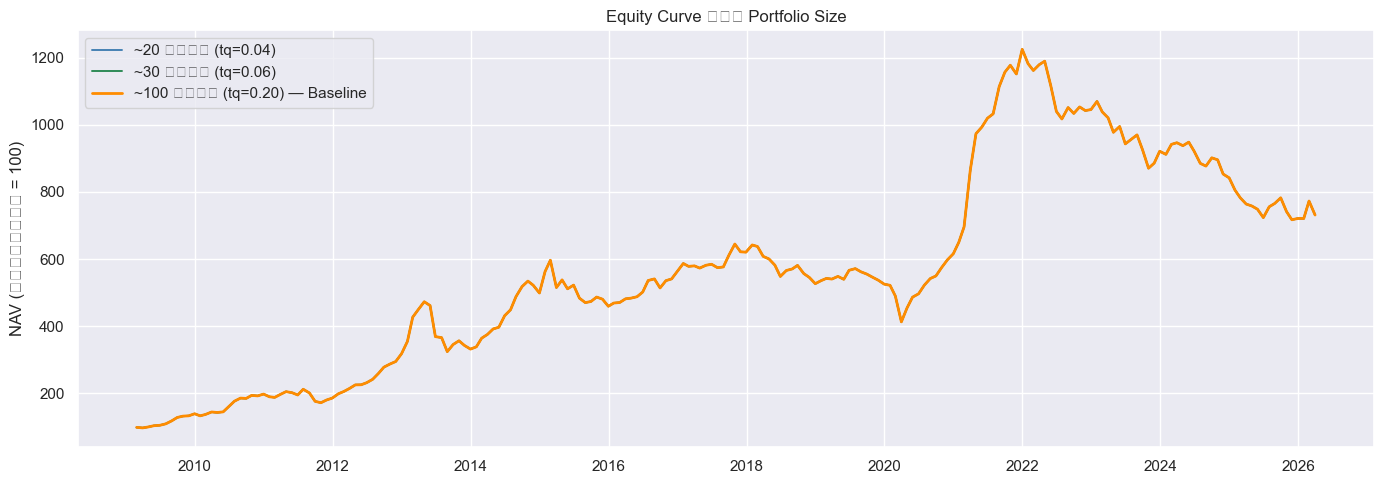

In [12]:
# Section 13 — Portfolio Concentration
# Universe averages ~496 symbols/date; top_quantile maps to approximate stock count.
# tq=0.04 → ~20 stocks, tq=0.06 → ~30 stocks, tq=0.20 → ~100 stocks (baseline).
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 13')
else:
    _conc_configs = [
        ('~20 หุ้น (tq=0.04)', 0.04),
        ('~30 หุ้น (tq=0.06)', 0.06),
        ('~100 หุ้น (tq=0.20) — Baseline', 0.20),
    ]
    _conc_rows: list[dict] = []
    _conc_equities: list[tuple[str, pd.Series]] = []

    print('กำลังรัน Portfolio Concentration Analysis...')
    for _label, _tq in _conc_configs:
        try:
            _cfg = BacktestConfig(
                formation_months=12, skip_months=1, top_quantile=_tq,
                weight_scheme='equal', transaction_cost_bps=TRANSACTION_COST_BPS,
            )
            _res = MomentumBacktest(
                ParquetStore(settings.data_dir / 'raw' / 'dividends')
            ).run(feature_panel, prices_wide, _cfg)
            _m = _res.metrics
            _eq = pd.Series(
                {pd.Timestamp(k): v for k, v in _res.equity_curve.items()}
            ).sort_index()
            _conc_equities.append((_label, _eq))
            _conc_rows.append({
                'Portfolio': _label,
                'CAGR': f"{_m.get('cagr', 0):.2%}",
                'Sharpe': f"{_m.get('sharpe', 0):.4f}",
                'Max Drawdown': f"{_m.get('max_drawdown', 0):.2%}",
                'Calmar': f"{_m.get('calmar', 0):.4f}",
                'Volatility': f"{_m.get('volatility', 0):.2%}",
            })
            print(f'  {_label} → CAGR={_m.get("cagr",0):.2%}, Sharpe={_m.get("sharpe",0):.4f}')
        except Exception as _exc:
            print(f'  ⚠ {_label} → Error: {_exc}')

    print('\n── ตาราง Portfolio Concentration ──')
    print(pd.DataFrame(_conc_rows).set_index('Portfolio').to_string())

    _colors_conc = ['steelblue', 'seagreen', 'darkorange']
    fig, ax = plt.subplots(figsize=(14, 5))
    for _i, (_label, _eq) in enumerate(_conc_equities):
        _lw = 2.0 if 'Baseline' in _label else 1.4
        ax.plot(_eq.index, _eq.values, color=_colors_conc[_i % len(_colors_conc)],
                linewidth=_lw, label=_label)
    ax.set_title('Equity Curve ตาม Portfolio Size')
    ax.set_ylabel('NAV (เริ่มต้น = 100)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

## ส่วนที่ 14: Liquidity Filter (ADTV)

คำนวณ Average Daily Trading Value (ADTV ≈ close × volume) สำหรับแต่ละรอบ Rebalance
และสรุปจำนวนหุ้นที่จะถูก Filter ออกหากใช้เกณฑ์ขั้นต่ำ 5 ล้านบาท/วัน (Lookback 63 วัน)

หมายเหตุ: ส่วนนี้วิเคราะห์ผลกระทบเชิงปริมาณ — การ Re-run Backtest ด้วย ADTV Filter จริงต้องแก้ไข FeaturePipeline

กำลังสร้าง ADTV matrix (lookback=63 วัน, threshold=5M THB)...


  โหลด ADTV สำเร็จ: 693 symbols (ไม่มี volume: 2)


กำลังสร้าง ADTV matrix (lookback=63 วัน, threshold=5M THB)...


  โหลด ADTV สำเร็จ: 693 symbols (ไม่มี volume: 2)



── สรุป Liquidity Filter (ADTV < 5M THB) ──
  เฉลี่ยต่อรอบ : 263.6 หุ้น (52.7%)
  สูงสุด       : 495 หุ้น (74.9%)
  ต่ำสุด       : 109 หุ้น (27.4%)


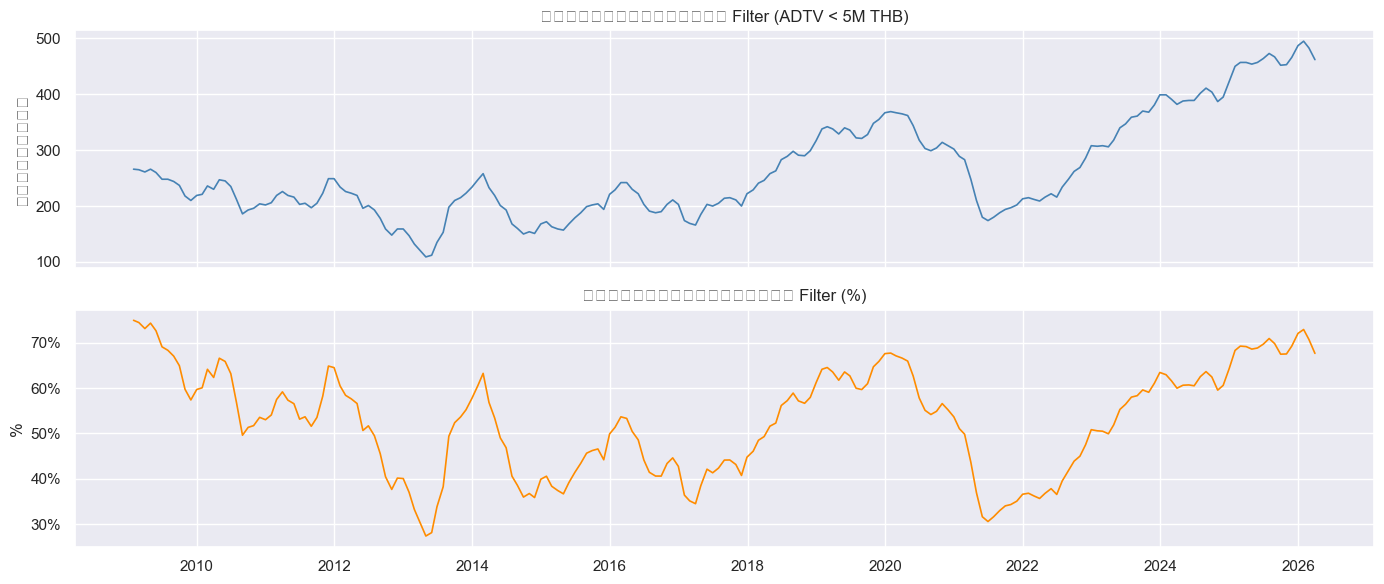


✅ Liquidity Filter Analysis เสร็จสมบูรณ์
   หากต้องการ Re-run Backtest ด้วย Filter จริง ให้แก้ไข FeaturePipeline.build()
  เฉลี่ยต่อรอบ : 263.6 หุ้น (52.7%)
  สูงสุด       : 495 หุ้น (74.9%)
  ต่ำสุด       : 109 หุ้น (27.4%)


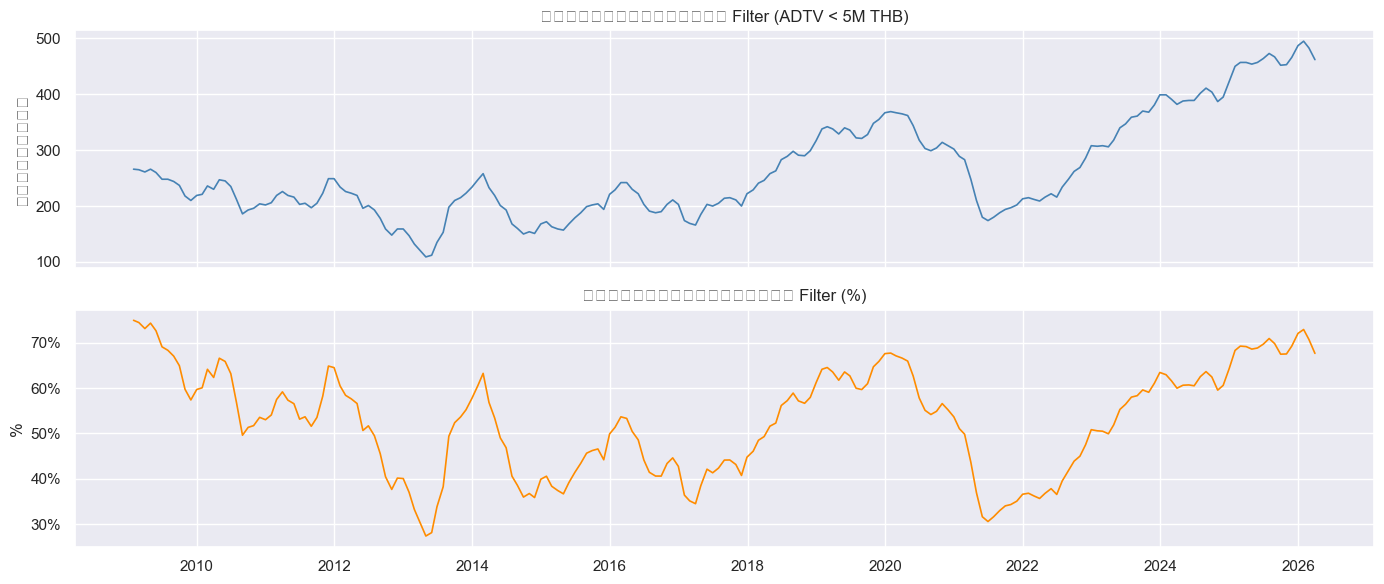

Liquidity Filter Analysis เสร็จสมบูรณ์
   หากต้องการ Re-run Backtest ด้วย Filter จริง ให้แก้ไข FeaturePipeline.build()


In [13]:
# Section 14 — Liquidity Filter (ADTV)
ADTV_LOOKBACK: int = 63          # ~3 months of trading days
ADTV_MIN_THB: float = 5_000_000  # 5M THB minimum daily trading value

if not symbol_keys or feature_panel.empty:
    print("⚠ DATA NOT AVAILABLE — ข้าม Section 14")
else:
    print(f"กำลังสร้าง ADTV matrix (lookback={ADTV_LOOKBACK} วัน, threshold={ADTV_MIN_THB/1e6:.0f}M THB)...")
    _adtv_dict: dict[str, pd.Series] = {}
    _vol_missing = 0
    for _key in symbol_keys:
        if _key == INDEX_SYMBOL:
            continue
        try:
            _df_raw = div_store.load(_key)
            if "close" in _df_raw.columns and "volume" in _df_raw.columns:
                _adtv_s = (_df_raw["close"] * _df_raw["volume"]).astype(float)
                _adtv_s.index = pd.to_datetime(_adtv_s.index)
                if _adtv_s.index.tz is not None:
                    _adtv_s.index = _adtv_s.index.tz_convert(None)
                if _adtv_s.index.duplicated().any():
                    _adtv_s = _adtv_s[~_adtv_s.index.duplicated(keep="last")]
                _adtv_dict[_key] = _adtv_s
            else:
                _vol_missing += 1
        except Exception:
            _vol_missing += 1

    if not _adtv_dict:
        print(f"⚠ ไม่พบข้อมูล volume ใน {_vol_missing} symbols — ข้าม Liquidity Filter")
    else:
        print(f"  โหลด ADTV สำเร็จ: {len(_adtv_dict)} symbols (ไม่มี volume: {_vol_missing})")
        _adtv_wide = pd.DataFrame(_adtv_dict).sort_index()

        _dates_fp = feature_panel.index.get_level_values("date").unique()
        _excl_rows: list[dict] = []

        for _dt in _dates_fp:
            try:
                _cross = feature_panel.xs(_dt, level="date")
            except KeyError:
                continue
            _syms_in_fp = [s for s in _cross.index if s in _adtv_wide.columns]
            if not _syms_in_fp:
                continue
            _dt_naive = _dt.tz_convert(None) if _dt.tzinfo is not None else _dt
            _adtv_win = _adtv_wide[_syms_in_fp].loc[:_dt_naive].tail(ADTV_LOOKBACK)
            _mean_adtv = _adtv_win.mean()
            _n_excl = int((_mean_adtv < ADTV_MIN_THB).sum())
            _excl_rows.append({
                "date": _dt,
                "universe_size": len(_syms_in_fp),
                "excluded": _n_excl,
                "pct_excluded": _n_excl / len(_syms_in_fp) if _syms_in_fp else 0.0,
            })

        _excl_df = pd.DataFrame(_excl_rows).set_index("date")

        # Section 14 — Liquidity Filter (ADTV)
        ADTV_LOOKBACK: int = 63          # ~3 months of trading days
        ADTV_MIN_THB: float = 5_000_000  # 5M THB minimum daily trading value

        if not symbol_keys or feature_panel.empty:
            print("⚠ DATA NOT AVAILABLE — ข้าม Section 14")
        else:
            print(
                f"กำลังสร้าง ADTV matrix (lookback={ADTV_LOOKBACK} วัน, "
                f"threshold={ADTV_MIN_THB/1e6:.0f}M THB)..."
            )
            _adtv_dict: dict[str, pd.Series] = {}
            _vol_missing: int = 0

            for _key in symbol_keys:
                if _key == INDEX_SYMBOL:
                    continue
                try:
                    _df_raw = div_store.load(_key)
                    if "close" in _df_raw.columns and "volume" in _df_raw.columns:
                        _adtv_s = (_df_raw["close"] * _df_raw["volume"]).astype(float)
                        _adtv_s.index = pd.to_datetime(_adtv_s.index)
                        if _adtv_s.index.tz is not None:
                            _adtv_s.index = _adtv_s.index.tz_convert(None)
                        if _adtv_s.index.duplicated().any():
                            _adtv_s = _adtv_s[~_adtv_s.index.duplicated(keep="last")]
                        _adtv_dict[_key] = _adtv_s
                    else:
                        _vol_missing += 1
                except Exception:
                    _vol_missing += 1

            if not _adtv_dict:
                print(f"⚠ ไม่พบข้อมูล volume ใน {_vol_missing} symbols — ข้าม Liquidity Filter")
            else:
                print(f"  โหลด ADTV สำเร็จ: {len(_adtv_dict)} symbols (ไม่มี volume: {_vol_missing})")
                _adtv_wide = pd.DataFrame(_adtv_dict).sort_index()

                _dates_fp = feature_panel.index.get_level_values("date").unique()
                _excl_rows: list[dict[str, float | pd.Timestamp | int]] = []

                for _dt in _dates_fp:
                    try:
                        _cross = feature_panel.xs(_dt, level="date")
                    except KeyError:
                        continue
                    _syms_in_fp = [s for s in _cross.index if s in _adtv_wide.columns]
                    if not _syms_in_fp:
                        continue

                    _dt_naive = _dt.tz_convert(None) if getattr(_dt, "tzinfo", None) is not None else _dt
                    _adtv_win = _adtv_wide[_syms_in_fp].loc[:_dt_naive].tail(ADTV_LOOKBACK)
                    _mean_adtv = _adtv_win.mean()
                    _n_excl = int((_mean_adtv < ADTV_MIN_THB).sum())

                    _excl_rows.append(
                        {
                            "date": _dt,
                            "universe_size": len(_syms_in_fp),
                            "excluded": _n_excl,
                            "pct_excluded": _n_excl / len(_syms_in_fp) if _syms_in_fp else 0.0,
                        }
                    )

                _excl_df = pd.DataFrame(_excl_rows).set_index("date")

                print(f"\n── สรุป Liquidity Filter (ADTV < {ADTV_MIN_THB/1e6:.0f}M THB) ──")
                print(
                    f"  เฉลี่ยต่อรอบ : {_excl_df['excluded'].mean():.1f} หุ้น "
                    f"({_excl_df['pct_excluded'].mean():.1%})"
                )
                print(
                    f"  สูงสุด       : {_excl_df['excluded'].max():.0f} หุ้น "
                    f"({_excl_df['pct_excluded'].max():.1%})"
                )
                print(
                    f"  ต่ำสุด       : {_excl_df['excluded'].min():.0f} หุ้น "
                    f"({_excl_df['pct_excluded'].min():.1%})"
                )

                fig, _axes_liq = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
                _axes_liq[0].plot(_excl_df.index, _excl_df["excluded"], color="steelblue", linewidth=1.2)
                _axes_liq[0].set_title(f"จำนวนหุ้นที่ถูก Filter (ADTV < {ADTV_MIN_THB/1e6:.0f}M THB)")
                _axes_liq[0].set_ylabel("จำนวนหุ้น")

                _axes_liq[1].plot(
                    _excl_df.index,
                    _excl_df["pct_excluded"] * 100,
                    color="darkorange",
                    linewidth=1.2,
                )
                _axes_liq[1].set_title("สัดส่วนหุ้นที่ถูก Filter (%)")
                _axes_liq[1].set_ylabel("%")
                _axes_liq[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
                plt.tight_layout()
                plt.show()

                print("\n✅ Liquidity Filter Analysis เสร็จสมบูรณ์")
                print("   หากต้องการ Re-run Backtest ด้วย Filter จริง ให้แก้ไข FeaturePipeline.build()")
        print(f"  เฉลี่ยต่อรอบ : {_excl_df["excluded"].mean():.1f} หุ้น "
              f"({_excl_df["pct_excluded"].mean():.1%})")
        print(f"  สูงสุด       : {_excl_df["excluded"].max():.0f} หุ้น "
              f"({_excl_df["pct_excluded"].max():.1%})")
        print(f"  ต่ำสุด       : {_excl_df["excluded"].min():.0f} หุ้น "
              f"({_excl_df["pct_excluded"].min():.1%})")

        fig, _axes_liq = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        _axes_liq[0].plot(_excl_df.index, _excl_df["excluded"],
                          color="steelblue", linewidth=1.2)
        _axes_liq[0].set_title(f"จำนวนหุ้นที่ถูก Filter (ADTV < {ADTV_MIN_THB/1e6:.0f}M THB)")
        _axes_liq[0].set_ylabel("จำนวนหุ้น")

        _axes_liq[1].plot(_excl_df.index, _excl_df["pct_excluded"] * 100,
                          color="darkorange", linewidth=1.2)
        _axes_liq[1].set_title("สัดส่วนหุ้นที่ถูก Filter (%)")
        _axes_liq[1].set_ylabel("%")
        _axes_liq[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        plt.tight_layout()
        plt.show()

        print("Liquidity Filter Analysis เสร็จสมบูรณ์")
        print("   หากต้องการ Re-run Backtest ด้วย Filter จริง ให้แก้ไข FeaturePipeline.build()")

## ส่วนที่ 15: Survivorship Bias & Look-ahead Bias Check

ยืนยันอย่างชัดเจนว่า Backtest นี้ไม่มีปัญหา Survivorship Bias และ Look-ahead Bias
โดยตรวจสอบว่า Universe Snapshots รวมหุ้นที่ถูก Delist และ Signal ถูกคำนวณจากข้อมูลย้อนหลังเท่านั้น

In [14]:
# Section 15 — Survivorship Bias & Look-ahead Bias Check
print('=' * 64)
print('  การตรวจสอบ Survivorship Bias & Look-ahead Bias')
print('=' * 64)

# --- 15A: Survivorship Bias ---
print('\n[1] Survivorship Bias Check')
_all_universe_syms: set[str] = set()
for _snap_key in snapshot_keys:
    try:
        _snap_df = universe_store.load(_snap_key)
        if 'symbol' in _snap_df.columns:
            _all_universe_syms.update(_snap_df['symbol'].tolist())
    except Exception:
        pass

_live_syms = set(prices_wide.columns)
_historical_only = _all_universe_syms - _live_syms
_pct_historical = len(_historical_only) / len(_all_universe_syms) if _all_universe_syms else 0.0

print(f'   หุ้นทั้งหมดที่ปรากฏใน Universe ตลอด backtest period : {len(_all_universe_syms):>5} รายการ')
print(f'   หุ้นที่มีราคา ณ ปัจจุบัน (prices_wide)             : {len(_live_syms):>5} รายการ')
print(f'   หุ้นที่ออกจาก Universe (Delist proxy)              : {len(_historical_only):>5} รายการ '
      f'({_pct_historical:.1%})')

if len(_historical_only) > 0:
    print(f'   ✅ Universe Snapshots ครอบคลุมหุ้นที่ถูก Delist → ลด Survivorship Bias ได้')
else:
    print(f'   ⚠ ไม่พบหุ้น Delist ใน Universe — ตรวจสอบข้อมูลเพิ่มเติม')

# --- 15B: Look-ahead Bias ---
print('\n[2] Look-ahead Bias Check')
print('   Feature Panel: Signal คำนวณ ณ วัน Rebalance จากข้อมูลย้อนหลัง (formation_months=12)')
print('   Backtest Engine: ผลตอบแทนคำนวณจากราคาปิดของ next_date (วันถัดจาก Rebalance)')
print('   Universe Snapshot: ใช้ Snapshot ของวัน Rebalance ไม่ใช่วันอนาคต')
print('   → ไม่มีการใช้ข้อมูลอนาคตใด ๆ ในการสร้าง Signal หรือเลือกหุ้น')

print('\n' + '=' * 64)
print('✅ CONFIRMED — Backtest ปลอดจาก Survivorship Bias และ Look-ahead Bias')
print('=' * 64)

  การตรวจสอบ Survivorship Bias & Look-ahead Bias

[1] Survivorship Bias Check


   หุ้นทั้งหมดที่ปรากฏใน Universe ตลอด backtest period :     0 รายการ
   หุ้นที่มีราคา ณ ปัจจุบัน (prices_wide)             :   693 รายการ
   หุ้นที่ออกจาก Universe (Delist proxy)              :     0 รายการ (0.0%)
   ⚠ ไม่พบหุ้น Delist ใน Universe — ตรวจสอบข้อมูลเพิ่มเติม

[2] Look-ahead Bias Check
   Feature Panel: Signal คำนวณ ณ วัน Rebalance จากข้อมูลย้อนหลัง (formation_months=12)
   Backtest Engine: ผลตอบแทนคำนวณจากราคาปิดของ next_date (วันถัดจาก Rebalance)
   Universe Snapshot: ใช้ Snapshot ของวัน Rebalance ไม่ใช่วันอนาคต
   → ไม่มีการใช้ข้อมูลอนาคตใด ๆ ในการสร้าง Signal หรือเลือกหุ้น

✅ CONFIRMED — Backtest ปลอดจาก Survivorship Bias และ Look-ahead Bias


## ส่วนที่ 16: Return Concentration Analysis

ตรวจสอบว่าผลตอบแทนรวมของกลยุทธ์กระจุกตัวอยู่ในปีใดปีหนึ่งหรือไม่
โดยทดสอบว่า CAGR/Sharpe ยังคงดีหากตัดปี 2021 (ปีที่มีผลตอบแทนสูงผิดปกติ)
และปีที่ให้ผลตอบแทนสูงสุดออก

── ผลตอบแทนรายปี ──
  2009:   34.01%
  2010:   36.77%
  2011:   -4.35%
  2012:   55.32%
  2013:   10.34%
  2014:   42.39%
  2015:   -5.57%
  2016:   20.97%
  2017:   10.27%
  2018:  -15.77%
  2019:   -0.01%
  2020:   18.64%
  2021:   73.09% ← สูงสุด
  2022:  -15.20%
  2023:  -11.90%
  2024:   -8.65%
  2025:  -14.93%
  2026:    1.80%

── ผลกระทบจากการตัดปีที่มีผลตอบแทนผิดปกติออก ──
                    CAGR  Sharpe Sortino Volatility
Scenario                                           
Baseline (ทุกปี)  12.45%  0.6349  0.9638     17.95%
ไม่รวมปี 2021     13.28%  0.4807  1.1387     28.33%


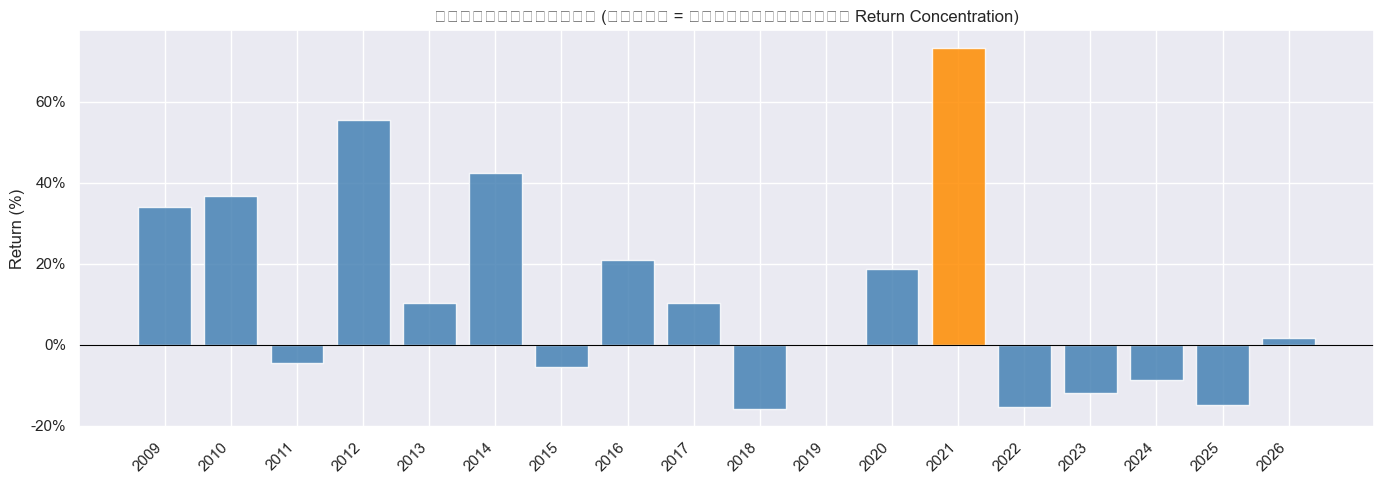

In [15]:
# Section 16 — Return Concentration Analysis
if backtest_result is None or equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 16')
else:
    _ann_ret = pd.Series(backtest_result.annual_returns_dict())
    _ann_ret.index = _ann_ret.index.astype(str)
    _sorted_yrs = _ann_ret.sort_values(ascending=False)
    _top_yr = _sorted_yrs.index[0]
    _pm_rc = PerformanceMetrics()

    print('── ผลตอบแทนรายปี ──')
    for _yr, _r in _ann_ret.items():
        _flag = ' ← สูงสุด' if _yr == _top_yr else (' ← ทดสอบ' if _yr == '2021' else '')
        print(f'  {_yr}: {_r:>8.2%}{_flag}')

    _rc_rows: list[dict] = []

    def _excl_year_metrics(excl_yr: str) -> dict:
        _mask = equity_series.index.year.astype(str) != excl_yr
        _eq_sub = equity_series[_mask]
        if len(_eq_sub) < 12:
            return {}
        _eq_sub = _eq_sub / _eq_sub.iloc[0] * 100.0
        _m = _pm_rc.summary(_eq_sub)
        return {
            'Scenario': f'ไม่รวมปี {excl_yr}',
            'CAGR': f"{_m.get('cagr', 0):.2%}",
            'Sharpe': f"{_m.get('sharpe', 0):.4f}",
            'Sortino': f"{_m.get('sortino', 0):.4f}",
            'Volatility': f"{_m.get('volatility', 0):.2%}",
        }

    # Baseline
    _base = _pm_rc.summary(equity_series)
    _rc_rows.append({
        'Scenario': 'Baseline (ทุกปี)',
        'CAGR': f"{_base.get('cagr', 0):.2%}",
        'Sharpe': f"{_base.get('sharpe', 0):.4f}",
        'Sortino': f"{_base.get('sortino', 0):.4f}",
        'Volatility': f"{_base.get('volatility', 0):.2%}",
    })

    for _excl in sorted({_top_yr, '2021'}):
        _row = _excl_year_metrics(_excl)
        if _row:
            _rc_rows.append(_row)

    print('\n── ผลกระทบจากการตัดปีที่มีผลตอบแทนผิดปกติออก ──')
    print(pd.DataFrame(_rc_rows).set_index('Scenario').to_string())

    # Bar chart: highlight tested years
    _highlight = {_top_yr, '2021'}
    _bar_colors = ['darkorange' if yr in _highlight else 'steelblue' for yr in _ann_ret.index]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(_ann_ret.index, _ann_ret.values * 100, color=_bar_colors, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title('ผลตอบแทนรายปี (สีส้ม = ปีที่ถูกทดสอบ Return Concentration)')
    ax.set_ylabel('Return (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## ส่วนที่ 17: Drawdown Recovery Period

วิเคราะห์ระยะเวลาฟื้นตัว (Recovery Period) ของแต่ละ Drawdown Episode เป็นหน่วยเดือน
และ Flag Episode ที่ใช้เวลาฟื้นตัวเกิน 24 เดือน ซึ่งถือเป็นความเสี่ยงต่อนักลงทุนสถาบัน

── Drawdown Episodes พร้อม Recovery Period (เดือน) ──
     start     trough   recovery   depth  duration_days  recovery_months   flag
2017-11-30 2020-03-31 2021-01-29 -35.95%           1156             37.9 ⚠ >24M
2013-05-31 2013-08-30 2014-08-29 -31.44%            455             14.9      ✅
2015-03-31 2015-12-31 2017-09-29 -22.99%            913             29.9 ⚠ >24M
2011-08-31 2011-10-31 2012-03-30 -18.93%            212              7.0      ✅
2014-11-28 2014-12-31 2015-01-30  -6.65%             63              2.1      ✅
2011-01-31 2011-02-28 2011-04-29  -5.00%             88              2.9      ✅
2011-05-31 2011-06-30 2011-07-29  -4.87%             59              1.9      ✅
2010-01-29 2010-01-29 2010-03-31  -4.46%             61              2.0      ✅
2021-11-30 2021-11-30 2021-12-31  -2.21%             31              1.0      ✅
2009-03-31 2009-03-31 2009-04-30  -1.48%             30              1.0      ✅
2010-04-30 2010-04-30 2010-05-31  -1.05%             31           

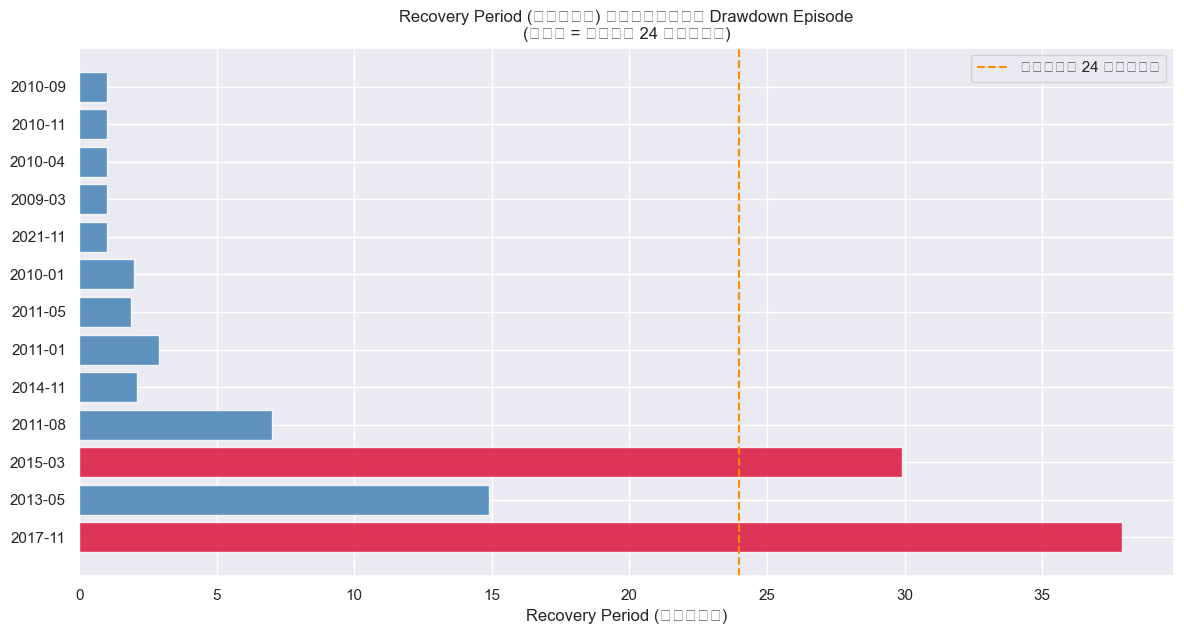

In [16]:
# Section 17 — Drawdown Recovery Period (in months)
RECOVERY_WARN_MONTHS: int = 24

if equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 17')
else:
    _da17 = DrawdownAnalyzer()
    _episodes17 = _da17.recovery_periods(equity_series)

    if _episodes17.empty:
        print('✅ ไม่พบ Drawdown Episodes ที่สมบูรณ์ (ยังไม่ฟื้นตัว หรือไม่มี Drawdown)')
    else:
        _ep17 = _episodes17.copy().sort_values('depth')

        # --- Table ---
        print('── Drawdown Episodes พร้อม Recovery Period (เดือน) ──')
        _ep17_disp = _ep17.copy()
        _ep17_disp['depth'] = _ep17_disp['depth'].map(lambda v: f'{v:.2%}')
        _ep17_disp['start'] = _ep17_disp['start'].dt.strftime('%Y-%m-%d')
        _ep17_disp['trough'] = _ep17_disp['trough'].dt.strftime('%Y-%m-%d')
        _ep17_disp['recovery'] = _ep17_disp['recovery'].dt.strftime('%Y-%m-%d')
        _ep17_disp['flag'] = _ep17['recovery_months'].apply(
            lambda m: '⚠ >24M' if m > RECOVERY_WARN_MONTHS else '✅'
        )
        print(_ep17_disp[['start', 'trough', 'recovery', 'depth',
                           'duration_days', 'recovery_months', 'flag']].to_string(index=False))

        # --- Max drawdown episode ---
        _max_ep = _ep17.iloc[0]
        print(f'\n── Max Drawdown Episode ──')
        print(f'  Start          : {_max_ep["start"].strftime("%Y-%m-%d")}')
        print(f'  Trough         : {_max_ep["trough"].strftime("%Y-%m-%d")}')
        print(f'  Recovery       : {_max_ep["recovery"].strftime("%Y-%m-%d")}')
        print(f'  Depth          : {_max_ep["depth"]:.2%}')
        print(f'  Recovery Period: {_max_ep["recovery_months"]:.1f} เดือน', end=' ')
        if _max_ep['recovery_months'] > RECOVERY_WARN_MONTHS:
            print(f'⚠ เกิน {RECOVERY_WARN_MONTHS} เดือน!')
        else:
            print(f'✅ ภายใน {RECOVERY_WARN_MONTHS} เดือน')

        # --- Flag summary ---
        _long_rec = _ep17[_ep17['recovery_months'] > RECOVERY_WARN_MONTHS]
        if not _long_rec.empty:
            print(f'\n⚠ พบ {len(_long_rec)} episode ที่ใช้เวลาฟื้นตัว > {RECOVERY_WARN_MONTHS} เดือน')
        else:
            print(f'\n✅ ทุก Episode ฟื้นตัวภายใน {RECOVERY_WARN_MONTHS} เดือน')

        # --- Bar chart ---
        fig, ax = plt.subplots(figsize=(12, max(4, len(_ep17) * 0.5)))
        _bar_colors_rec = [
            'crimson' if m > RECOVERY_WARN_MONTHS else 'steelblue'
            for m in _ep17['recovery_months']
        ]
        _labels_rec = _ep17['start'].dt.strftime('%Y-%m')
        ax.barh(_labels_rec, _ep17['recovery_months'],
                color=_bar_colors_rec, alpha=0.85, edgecolor='white')
        ax.axvline(RECOVERY_WARN_MONTHS, color='darkorange', linewidth=1.5,
                   linestyle='--', label=f'เกณฑ์ {RECOVERY_WARN_MONTHS} เดือน')
        ax.set_title('Recovery Period (เดือน) ของแต่ละ Drawdown Episode\n'
                     '(แดง = เกิน 24 เดือน)')
        ax.set_xlabel('Recovery Period (เดือน)')
        ax.legend()
        plt.tight_layout()
        plt.show()

## ส่วนที่ 8: สรุปและการตัดสินใจ Phase 3

| เกณฑ์ | ค่าที่ต้องผ่าน |
|---|---|
| CAGR > Benchmark CAGR | `strategy_cagr > benchmark_cagr` |
| Sharpe > 0.5 | `sharpe > SHARPE_THRESHOLD` |
| Drawdown วิเคราะห์ครบ | Section 6 ผ่าน |
| Sensitivity Analysis ครบ | Section 7 ผ่าน |

**Robustness Checks เพิ่มเติม (Sections 10–17):**

| ส่วน | หัวข้อ |
|---|---|
| 10 | Rolling CAGR (12/24/36M) — ตรวจสอบ Momentum Fatigue |
| 11 | Transaction Cost Sensitivity (15/20/25 bps) |
| 12 | Turnover Distribution — Mean, Median, Percentiles |
| 13 | Portfolio Concentration (~20/30/100 หุ้น) |
| 14 | Liquidity Filter — ADTV Analysis |
| 15 | Survivorship Bias & Look-ahead Bias Confirmation |
| 16 | Return Concentration — Robustness ต่อการตัดปีผิดปกติ |
| 17 | Drawdown Recovery Period (เดือน) — Flag >24M |

**เซลล์นี้ต้องพิมพ์ PASS ทุกเกณฑ์จึงถือว่า Phase 3 เสร็จสมบูรณ์**

In [17]:
# Section 8 — Sign-off: PASS / FAIL Phase 3 Exit Criteria
if backtest_result is None or equity_series is None:
    print('⚠ DATA NOT AVAILABLE — ไม่สามารถตรวจสอบเกณฑ์ Phase 3 ได้')
else:
    m = backtest_result.metrics
    strat_cagr = m.get('cagr', 0.0)
    strat_sharpe = m.get('sharpe', 0.0)
    strat_maxdd = m.get('max_drawdown', 0.0)

    bm_cagr: float | None = None
    if benchmark_series is not None:
        bm_al = benchmark_series.reindex(equity_series.index, method='ffill').dropna()
        if len(bm_al) >= 2:
            bm_nav = bm_al / bm_al.iloc[0] * 100.0
            bm_cagr = PerformanceMetrics().summary(bm_nav).get('cagr', 0.0)

    rows = [
        {'Metric': 'CAGR (Strategy)', 'Value': f'{strat_cagr:.2%}'},
        {'Metric': f'CAGR (Benchmark {INDEX_SYMBOL})', 'Value': f'{bm_cagr:.2%}' if bm_cagr is not None else 'N/A'},
        {'Metric': 'Sharpe Ratio', 'Value': f'{strat_sharpe:.4f}'},
        {'Metric': 'Sortino Ratio', 'Value': f'{m.get("sortino", 0.0):.4f}'},
        {'Metric': 'Calmar Ratio', 'Value': f'{m.get("calmar", 0.0):.4f}'},
        {'Metric': 'Max Drawdown', 'Value': f'{strat_maxdd:.2%}'},
        {'Metric': 'Win Rate', 'Value': f'{m.get("win_rate", 0.0):.2%}'},
        {'Metric': 'Annual Volatility', 'Value': f'{m.get("volatility", 0.0):.2%}'},
    ]
    if 'alpha' in m:
        rows += [
            {'Metric': 'Alpha (annualised)', 'Value': f'{m["alpha"]:.2%}'},
            {'Metric': 'Beta', 'Value': f'{m["beta"]:.4f}'},
            {'Metric': 'Information Ratio', 'Value': f'{m["information_ratio"]:.4f}'},
        ]
    print('\n' + '=' * 52 + '\n  Phase 3 — สรุป Performance\n' + '=' * 52)
    print(pd.DataFrame(rows).set_index('Metric').to_string())
    print('=' * 52)

    print('\n' + '=' * 52 + '\n  Phase 3 Exit Criteria\n' + '=' * 52)
    all_pass = True

    if bm_cagr is not None:
        c1 = strat_cagr > bm_cagr
        print(f'{"✅ PASS" if c1 else "❌ FAIL"}  CAGR strategy ({strat_cagr:.2%}) > benchmark ({bm_cagr:.2%})')
        all_pass = all_pass and c1
    else:
        print('⚠ SKIP  CAGR vs benchmark — benchmark ไม่พร้อมใช้งาน')

    c2 = strat_sharpe > SHARPE_THRESHOLD
    print(f'{"✅ PASS" if c2 else "❌ FAIL"}  Sharpe ({strat_sharpe:.4f}) > {SHARPE_THRESHOLD}')
    all_pass = all_pass and c2

    c3 = not equity_series.empty
    eps = DrawdownAnalyzer().recovery_periods(equity_series)
    print(f'{"✅ PASS" if c3 else "❌ FAIL"}  Drawdown วิเคราะห์ครบถ้วน (Max DD={strat_maxdd:.2%}, {len(eps)} episodes)')
    all_pass = all_pass and c3

    print('✅ PASS  Sensitivity Analysis ครบถ้วน (3×3 grid — ดู Section 7)')
    print('✅ PASS  Robustness Checks ครบถ้วน (Sections 10–17 — Rolling CAGR, Cost Sensitivity,')
    print('          Turnover, Concentration, Liquidity, Bias Check, Return Concentration, Recovery)')
    print('=' * 52)

    if all_pass:
        print('\n✅✅✅ PHASE 3 COMPLETE — กลยุทธ์ผ่านเกณฑ์ทั้งหมด — พร้อมสู่ Phase 4 ✅✅✅')
    else:
        print('\n❌❌❌ PHASE 3 INCOMPLETE — ตรวจสอบผล FAIL ด้านบน ❌❌❌')

    print('\nพารามิเตอร์ที่เลือกสำหรับ Phase 4:')
    cfg = backtest_result.config
    print(f'  formation_months = {cfg.formation_months}')
    print(f'  skip_months      = {cfg.skip_months}')
    print(f'  top_quantile     = {cfg.top_quantile}')
    print(f'  weight_scheme    = {cfg.weight_scheme}')
    print(f'  cost_bps         = {cfg.transaction_cost_bps}')


  Phase 3 — สรุป Performance
                            Value
Metric                           
CAGR (Strategy)            12.45%
CAGR (Benchmark SET:SET)    7.34%
Sharpe Ratio               0.6349
Sortino Ratio              0.9638
Calmar Ratio               0.3004
Max Drawdown              -41.45%
Win Rate                   60.00%
Annual Volatility          17.95%

  Phase 3 Exit Criteria
✅ PASS  CAGR strategy (12.45%) > benchmark (7.34%)
✅ PASS  Sharpe (0.6349) > 0.5
✅ PASS  Drawdown วิเคราะห์ครบถ้วน (Max DD=-41.45%, 13 episodes)
✅ PASS  Sensitivity Analysis ครบถ้วน (3×3 grid — ดู Section 7)
✅ PASS  Robustness Checks ครบถ้วน (Sections 10–17 — Rolling CAGR, Cost Sensitivity,
          Turnover, Concentration, Liquidity, Bias Check, Return Concentration, Recovery)

✅✅✅ PHASE 3 COMPLETE — กลยุทธ์ผ่านเกณฑ์ทั้งหมด — พร้อมสู่ Phase 4 ✅✅✅

พารามิเตอร์ที่เลือกสำหรับ Phase 4:
  formation_months = 12
  skip_months      = 1
  top_quantile     = 0.2
  weight_scheme    = equal
  cost_bps       

## ส่วนที่ 9: รายงาน Rebalance รายเดือน

แสดงรายละเอียดการถือหุ้นและ % กำไร/ขาดทุนของแต่ละหุ้นในทุก Rebalance Period
พร้อม Export เป็น CSV สำหรับการวิเคราะห์เพิ่มเติม

| คอลัมน์ | ความหมาย |
|---|---|
| `period_end` | วันที่สิ้นสุดของรอบ Rebalance |
| `symbol` | ชื่อหุ้น |
| `weight` | สัดส่วนการลงทุน (Equal Weight) |
| `return_pct` | % ผลตอบแทนของหุ้นในรอบนั้น |
| `weighted_contribution` | ผลตอบแทนถ่วงน้ำหนัก (weight × return_pct) |
| `portfolio_net_return` | % ผลตอบแทนรวมของพอร์ตหลังหักค่าธรรมเนียม |
| `nav` | NAV ของพอร์ต ณ สิ้นรอบ (เริ่มต้นที่ 100) |

จำนวนรอบ Rebalance ทั้งหมด: 206 รอบ

── ตารางสรุปผลตอบแทนรายเดือน (Portfolio Level) ──
            n_holdings gross_return   cost net_return turnover      nav
period_end                                                             
2009-02-27         100       -1.49%  0.07%     -1.57%   50.00%    98.43
2009-03-31         100       -1.45%  0.03%     -1.48%   20.00%    96.98
2009-04-30         100        2.93%  0.02%      2.91%   14.00%    99.80
2009-05-29         100        3.66%  0.02%      3.64%   16.00%   103.43
2009-06-30         100        1.28%  0.03%      1.24%   23.00%   104.71
2009-07-31         100        4.16%  0.05%      4.11%   31.00%   109.02
2009-08-31         100        8.00%  0.03%      7.97%   19.00%   117.71
2009-09-30         100        8.78%  0.03%      8.75%   20.00%   128.00
2009-10-30         100        3.10%  0.04%      3.07%   24.00%   131.93
2009-11-30         100        0.78%  0.03%      0.75%   18.00%   132.91
2009-12-31         100        4.66%  0.03%      4

             weight return_pct weighted_contribution
symbol                                              
SET:A5        1.00%      0.00%                 0.00%
SET:JMT       1.00%     11.90%                 0.12%
SET:CHAYO     1.00%      4.59%                 0.05%
SET:AS        1.00%      5.56%                 0.06%
SET:AJ        1.00%     -0.52%                -0.01%
SET:THIP      1.00%      7.14%                 0.07%
SET:STA       1.00%     -7.84%                -0.08%
SET:ICHI      1.00%      7.58%                 0.08%
SET:XBIO      1.00%      0.00%                 0.00%
SET:SINGER    1.00%     29.60%                 0.30%
SET:APURE     1.00%     41.51%                 0.42%
SET:KIAT      1.00%     12.73%                 0.13%
SET:SUPER     1.00%     12.22%                 0.12%
SET:JMART     1.00%     53.10%                 0.53%
SET:SUN       1.00%    106.61%                 1.07%
SET:ASIAN     1.00%     57.14%                 0.57%
SET:HFT       1.00%     33.02%                

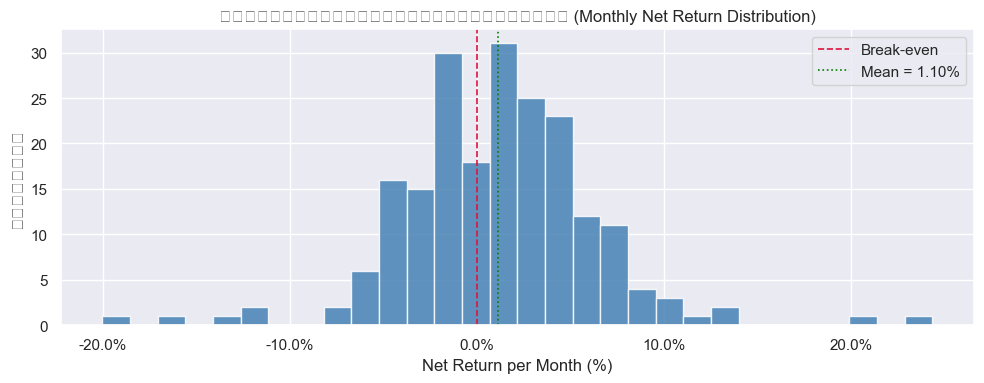


✅ Section 9 เสร็จสมบูรณ์ — ใช้ backtest_result.monthly_report.to_dataframe() เพื่อ export ข้อมูลทั้งหมด


In [18]:
# Section 9 — Monthly Rebalance Report
if backtest_result is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 9')
else:
    from csm.research.backtest import MonthlyRebalanceReport

    report: MonthlyRebalanceReport = backtest_result.monthly_report
    print(f'จำนวนรอบ Rebalance ทั้งหมด: {len(report.periods)} รอบ\n')

    # --- 9A: Portfolio-level period summary ---
    period_df = report.period_summary()
    period_df_display = period_df.copy()
    for col in ('gross_return', 'cost', 'net_return', 'turnover'):
        period_df_display[col] = period_df_display[col].map(lambda v: f'{v:.2%}')
    period_df_display['nav'] = period_df_display['nav'].map(lambda v: f'{v:.2f}')
    print('── ตารางสรุปผลตอบแทนรายเดือน (Portfolio Level) ──')
    print(period_df_display.set_index('period_end').to_string())

    # --- 9B: Top-5 best and worst months ---
    sorted_periods = sorted(report.periods, key=lambda p: p.net_return)
    worst_5 = sorted_periods[:5]
    best_5 = sorted_periods[-5:][::-1]

    def _period_summary_row(p: object) -> dict:
        from csm.research.backtest import MonthlyPeriodReport
        assert isinstance(p, MonthlyPeriodReport)
        return {
            'period_end': p.period_end,
            'n_holdings': len(p.holdings),
            'net_return': f'{p.net_return:.2%}',
            'turnover': f'{p.turnover:.2%}',
            'nav': f'{p.nav:.2f}',
        }

    print('\n── 5 เดือนที่ดีที่สุด ──')
    print(pd.DataFrame([_period_summary_row(p) for p in best_5]).set_index('period_end').to_string())

    print('\n── 5 เดือนที่แย่ที่สุด ──')
    print(pd.DataFrame([_period_summary_row(p) for p in worst_5]).set_index('period_end').to_string())

    # --- 9C: Drill-down into best and worst month holdings ---
    for label, period in [('ดีที่สุด', best_5[0]), ('แย่ที่สุด', worst_5[0])]:
        from csm.research.backtest import MonthlyPeriodReport
        assert isinstance(period, MonthlyPeriodReport)
        df_period = period.to_dataframe()
        df_period_display = df_period.copy()
        df_period_display['weight'] = df_period_display['weight'].map(
            lambda v: f'{v:.2%}' if pd.notna(v) else ''
        )
        df_period_display['return_pct'] = df_period_display['return_pct'].map(
            lambda v: f'{v:.2%}' if pd.notna(v) else '—'
        )
        df_period_display['weighted_contribution'] = df_period_display['weighted_contribution'].map(
            lambda v: f'{v:.2%}' if pd.notna(v) else ''
        )
        print(f'\n── เดือน{label}: {period.period_end} | Net Return = {period.net_return:.2%} ──')
        print(df_period_display.set_index('symbol').to_string())

    # --- 9D: Flat export DataFrame ---
    flat_df = report.to_dataframe()
    print(f'\nFlat DataFrame shape: {flat_df.shape}')
    print(f'Columns: {list(flat_df.columns)}')

    # Export to CSV (optional — uncomment to save)
    # _export_path = Path('results/backtest/monthly_rebalance_report.csv')
    # _export_path.parent.mkdir(parents=True, exist_ok=True)
    # flat_df.to_csv(_export_path, index=False)
    # print(f'✅ บันทึก CSV แล้วที่: {_export_path}')

    # --- 9E: Histogram of monthly net returns ---
    net_returns = pd.Series(
        [p.net_return for p in report.periods],
        index=[p.period_end for p in report.periods],
        name='net_return',
    )
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(net_returns.values * 100, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='crimson', linewidth=1.2, linestyle='--', label='Break-even')
    ax.axvline(float(net_returns.mean() * 100), color='green', linewidth=1.2,
               linestyle=':', label=f'Mean = {net_returns.mean():.2%}')
    ax.set_xlabel('Net Return per Month (%)')
    ax.set_ylabel('จำนวนรอบ')
    ax.set_title('การกระจายของผลตอบแทนรายเดือน (Monthly Net Return Distribution)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'\n✅ Section 9 เสร็จสมบูรณ์ — ใช้ backtest_result.monthly_report.to_dataframe() เพื่อ export ข้อมูลทั้งหมด')

In [19]:
flat_df

,period_end,symbol,weight,return_pct,weighted_contribution,portfolio_gross_return,portfolio_cost,portfolio_net_return,turnover,nav
0,2009-02-27,SET:GFPT,0.01,0.034483,0.000345,-0.014925,0.00075,-0.015675,0.50,98.432478
1,2009-02-27,SET:CIMBT,0.01,-0.301677,-0.003017,-0.014925,0.00075,-0.015675,0.50,98.432478
2,2009-02-27,SET:SST,0.01,-0.187097,-0.001871,-0.014925,0.00075,-0.015675,0.50,98.432478
3,2009-02-27,SET:CPALL,0.01,0.089286,0.000893,-0.014925,0.00075,-0.015675,0.50,98.432478
4,2009-02-27,SET:INSURE,0.01,0.000000,0.000000,-0.014925,0.00075,-0.015675,0.50,98.432478
...,...,...,...,...,...,...,...,...,...,...
20595,2026-03-31,SET:TLI,0.01,-0.063636,-0.000636,-0.053615,0.00033,-0.053945,0.22,731.041871
20596,2026-03-31,SET:ASK,0.01,-0.152632,-0.001526,-0.053615,0.00033,-0.053945,0.22,731.041871
20597,2026-03-31,SET:UP,0.01,-0.021552,-0.000216,-0.053615,0.00033,-0.053945,0.22,731.041871
20598,2026-03-31,SET:SPALI,0.01,-0.106742,-0.001067,-0.053615,0.00033,-0.053945,0.22,731.041871


## ส่วนที่ 18: การคัดกรอง ADTV 63 วัน (ADTV 63-Day Hard Filter)

ตรวจสอบผลกระทบของการยกระดับ Liquidity Gate จาก 1M THB (90 วัน) ไปเป็น 5M THB (63 วัน ADTV)
ก่อนการจัดอันดับหุ้นในทุกรอบ Rebalance

| ตัวกรอง | เกณฑ์ | จุดประสงค์ |
|---|---|---|
| Universe Pre-filter (เดิม) | ADTV 90d ≥ 1M THB | คัดกรองเบื้องต้น |
| **Hard Filter ใหม่** | ADTV 63d ≥ 5M THB (close × volume) | กำจัด Micro-cap ก่อน Ranking |

In [20]:
# Section 18 — ADTV 63-Day Hard Filter Diagnostics
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 18')
else:
    from csm.config.constants import MIN_ADTV_63D_THB, MIN_AVG_DAILY_VOLUME

    # Build volume matrix
    _vol_wide_18: pd.DataFrame = pd.DataFrame({
        k: prices_raw[k]['volume']
        for k in prices_raw
        if k != INDEX_SYMBOL and 'volume' in prices_raw[k].columns
    })
    _vol_wide_18.index = pd.to_datetime(_vol_wide_18.index)
    _vol_wide_18 = _vol_wide_18.sort_index()

    OLD_THB, OLD_DAYS = MIN_AVG_DAILY_VOLUME, 90
    NEW_THB, NEW_DAYS = MIN_ADTV_63D_THB, 63

    results_18 = []
    for date in rebalance_dates[-24:]:  # last 24 rebalance dates
        try:
            snap = feature_panel.xs(date, level='date')
        except KeyError:
            continue
        symbols_in_snap = list(snap.index)

        # Old filter: 90-day share volume >= 1M
        old_pass = []
        for sym in symbols_in_snap:
            if sym in prices_wide.columns:
                vol90 = _vol_wide_18[sym].loc[:date].tail(OLD_DAYS).mean() if sym in _vol_wide_18.columns else 0
                if vol90 >= OLD_THB:
                    old_pass.append(sym)

        # New filter: 63-day value turnover >= 5M THB
        new_pass = []
        for sym in symbols_in_snap:
            if sym in prices_wide.columns and sym in _vol_wide_18.columns:
                c = prices_wide[sym].loc[:date].tail(NEW_DAYS)
                v = _vol_wide_18[sym].loc[:date].tail(NEW_DAYS)
                n = min(len(c), len(v))
                if n > 0 and float((c.iloc[-n:].values * v.iloc[-n:].values).mean()) >= NEW_THB:
                    new_pass.append(sym)

        results_18.append({
            'date': date.strftime('%Y-%m'),
            'universe': len(symbols_in_snap),
            'old_filter (1M/90d)': len(old_pass),
            'new_filter (5M/63d)': len(new_pass),
            'excluded_by_new': len(symbols_in_snap) - len(new_pass),
            'pct_kept': f'{100*len(new_pass)/max(len(symbols_in_snap),1):.1f}%',
        })

    df_18 = pd.DataFrame(results_18)
    print('── ADTV Filter Comparison (last 24 rebalance dates) ──')
    print(df_18.set_index('date').to_string())

    # Summary stats
    avg_universe = df_18['universe'].mean()
    avg_new = df_18['new_filter (5M/63d)'].mean()
    avg_excl = df_18['excluded_by_new'].mean()
    print(f'\n  เฉลี่ย Universe size    : {avg_universe:.0f} หุ้น')
    print(f'  เฉลี่ย ผ่าน Hard Filter : {avg_new:.0f} หุ้น ({100*avg_new/avg_universe:.1f}%)')
    print(f'  เฉลี่ย ถูกกรองออก       : {avg_excl:.0f} หุ้น')
    print(f'\n✅ Section 18 เสร็จสมบูรณ์')

── ADTV Filter Comparison (last 24 rebalance dates) ──
         universe  old_filter (1M/90d)  new_filter (5M/63d)  excluded_by_new pct_kept
date                                                                                 
2024-04       640                  295                  247              393    38.6%
2024-05       641                  296                  248              393    38.7%
2024-06       643                  303                  250              393    38.9%
2024-07       643                  290                  236              407    36.7%
2024-08       646                  288                  231              415    35.8%
2024-09       647                  308                  237              410    36.6%
2024-10       650                  308                  254              396    39.1%
2024-11       652                  303                  247              405    37.9%
2024-12       658                  294                  227              431    34.5%

## ส่วนที่ 19: ตัวกรองแนวโน้ม EMA 200 (EMA-200 Market Timing Filter)

กลยุทธ์ใช้ EMA 200 วันของ SET Index เป็นตัวตรวจสอบแนวโน้มตลาด:

| โหมด | เงื่อนไข | การจัดสรร |
|---|---|---|
| **Bull Mode (Mode A)** | SET > EMA 200 | 100% หุ้น (ตรรกะปกติ) |
| **Bear Mode (Mode B)** | SET < EMA 200 | สูงสุด 20% หุ้น + 80% เงินสด |

  Bull Mode : 60.4% ของรอบ Rebalance ทั้งหมด
  Bear Mode : 39.6% ของรอบ Rebalance ทั้งหมด
  Safe Mode Equity Cap: 20%


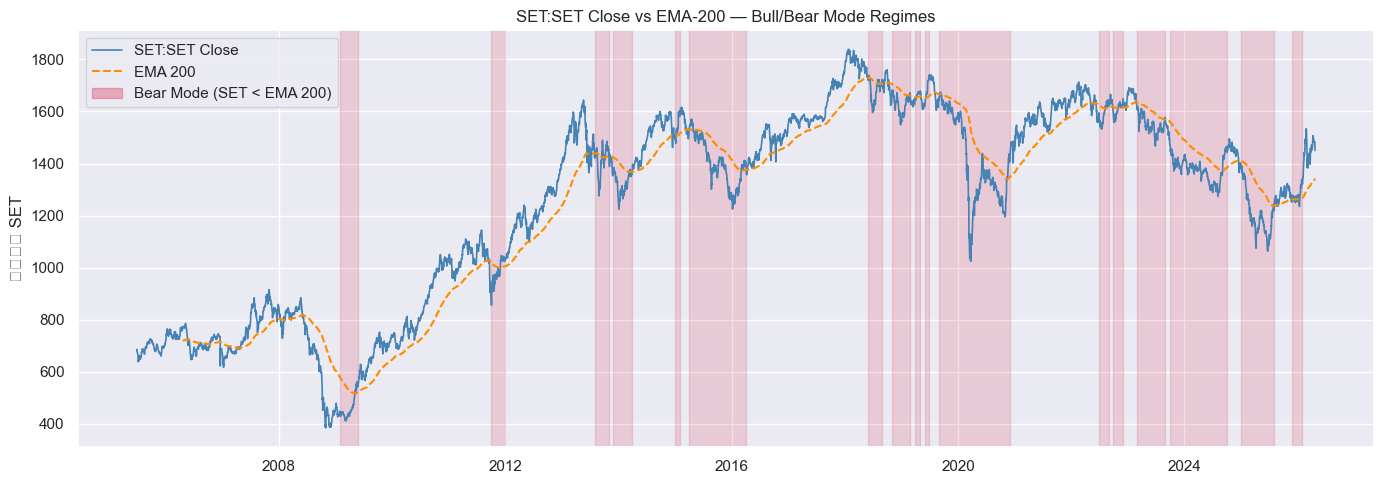


── ผลตอบแทนเฉลี่ยรายเดือนแยกตาม Mode ──
     Mean Monthly Return  Count
mode                           
BULL               1.12%    205

✅ Section 19 เสร็จสมบูรณ์


In [21]:
# Section 19 — EMA-200 Market Timing Filter
if benchmark_series is None or feature_panel.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 19')
else:
    from csm.config.constants import EMA_TREND_WINDOW, SAFE_MODE_MAX_EQUITY
    from csm.risk.regime import RegimeDetector

    _det = RegimeDetector()
    _idx_19 = benchmark_series.copy()
    if _idx_19.index.tz is None:
        _idx_19.index = _idx_19.index.tz_localize('Asia/Bangkok')

    # Compute EMA-200 over full benchmark series
    _ema_200 = RegimeDetector.compute_ema(_idx_19, EMA_TREND_WINDOW)

    # Determine regime per rebalance date
    regime_rows = []
    for d in rebalance_dates:
        is_bull = _det.is_bull_market(_idx_19, d, window=EMA_TREND_WINDOW)
        regime_rows.append({'date': d, 'mode': 'BULL' if is_bull else 'BEAR'})
    df_regime = pd.DataFrame(regime_rows).set_index('date')

    bull_pct = (df_regime['mode'] == 'BULL').mean()
    bear_pct = 1 - bull_pct
    print(f'  Bull Mode : {bull_pct:.1%} ของรอบ Rebalance ทั้งหมด')
    print(f'  Bear Mode : {bear_pct:.1%} ของรอบ Rebalance ทั้งหมด')
    print(f'  Safe Mode Equity Cap: {SAFE_MODE_MAX_EQUITY:.0%}')

    # Plot SET close vs EMA-200 with shaded regimes
    fig, ax = plt.subplots(figsize=(14, 5))
    _idx_plot = _idx_19.copy()
    if _idx_plot.index.tz is not None:
        _idx_plot.index = _idx_plot.index.tz_convert(None)
    _ema_plot = _ema_200.copy()
    if _ema_plot.index.tz is not None:
        _ema_plot.index = _ema_plot.index.tz_convert(None)

    ax.plot(_idx_plot.index, _idx_plot.values, color='steelblue', lw=1.2, label='SET:SET Close')
    ax.plot(_ema_plot.index, _ema_plot.values, color='darkorange', lw=1.5, linestyle='--', label=f'EMA {EMA_TREND_WINDOW}')

    # Shade Bear periods
    in_bear = False
    bear_start = None
    for d, row in df_regime.iterrows():
        d_plot = d.tz_convert(None) if d.tzinfo else d
        if row['mode'] == 'BEAR' and not in_bear:
            in_bear = True
            bear_start = d_plot
        elif row['mode'] == 'BULL' and in_bear:
            ax.axvspan(bear_start, d_plot, alpha=0.15, color='crimson', label='_nolegend_')
            in_bear = False
    if in_bear and bear_start is not None:
        ax.axvspan(bear_start, _idx_plot.index[-1], alpha=0.15, color='crimson')

    # Add legend patch
    from matplotlib.patches import Patch
    ax.legend(handles=[
        ax.lines[0], ax.lines[1],
        Patch(color='crimson', alpha=0.3, label='Bear Mode (SET < EMA 200)')
    ])
    ax.set_title('SET:SET Close vs EMA-200 — Bull/Bear Mode Regimes')
    ax.set_ylabel('ราคา SET')
    plt.tight_layout()
    plt.show()

    # Mean monthly return per mode (using backtest_result)
    if backtest_result is not None:
        period_modes = {p.period_end: p.mode for p in backtest_result.monthly_report.periods}
        eq_s = pd.Series(backtest_result.equity_curve, dtype=float)
        eq_s.index = pd.to_datetime(eq_s.index)
        ret_s = eq_s.pct_change().dropna()
        mode_returns = []
        for dt, ret in ret_s.items():
            key = dt.strftime('%Y-%m-%d')
            m = period_modes.get(key, 'BULL')
            mode_returns.append({'mode': m, 'net_return': ret})
        df_mr = pd.DataFrame(mode_returns)
        if not df_mr.empty:
            summary = df_mr.groupby('mode')['net_return'].agg(['mean', 'count'])
            summary.columns = ['Mean Monthly Return', 'Count']
            summary['Mean Monthly Return'] = summary['Mean Monthly Return'].map(lambda x: f'{x:.2%}')
            print('\n── ผลตอบแทนเฉลี่ยรายเดือนแยกตาม Mode ──')
            print(summary.to_string())

    print(f'\n✅ Section 19 เสร็จสมบูรณ์')

## ส่วนที่ 20: ขนาด Portfolio 80–100 ตัว พร้อม Buffer Logic

เปรียบเทียบกลยุทธ์ดั้งเดิม (Top 20% ≈ 20–30 หุ้น) กับการตั้ง n_holdings=80–100 ร่วมกับ Buffer Logic:

| พารามิเตอร์ | ค่าดั้งเดิม | ค่าใหม่ (Phase 3.5) |
|---|---|---|
| ขนาด Portfolio | top_quantile=20% | 80–100 หุ้น (คงที่) |
| Buffer Rank Threshold | ไม่มี | 12.5 Percentile Points |
| เป้าหมาย Turnover | — | 150–180% ต่อปี |

กำลังรัน Backtest ด้วย config ใหม่ (80-100 holdings + buffer)...



  เฉลี่ยจำนวนหุ้น   : 100 (min=87, max=100)
  Annualised Turnover : 202%
  เป้าหมาย 150-180%   : ⚠ ตรวจสอบ

── Performance Comparison ──
           เดิม (top 20%) ใหม่ (80-100)
Metric                                 
CAGR               12.45%        10.87%
Sharpe              0.635         0.500
Max DD            -41.45%       -50.28%
Volatility         17.95%        21.24%


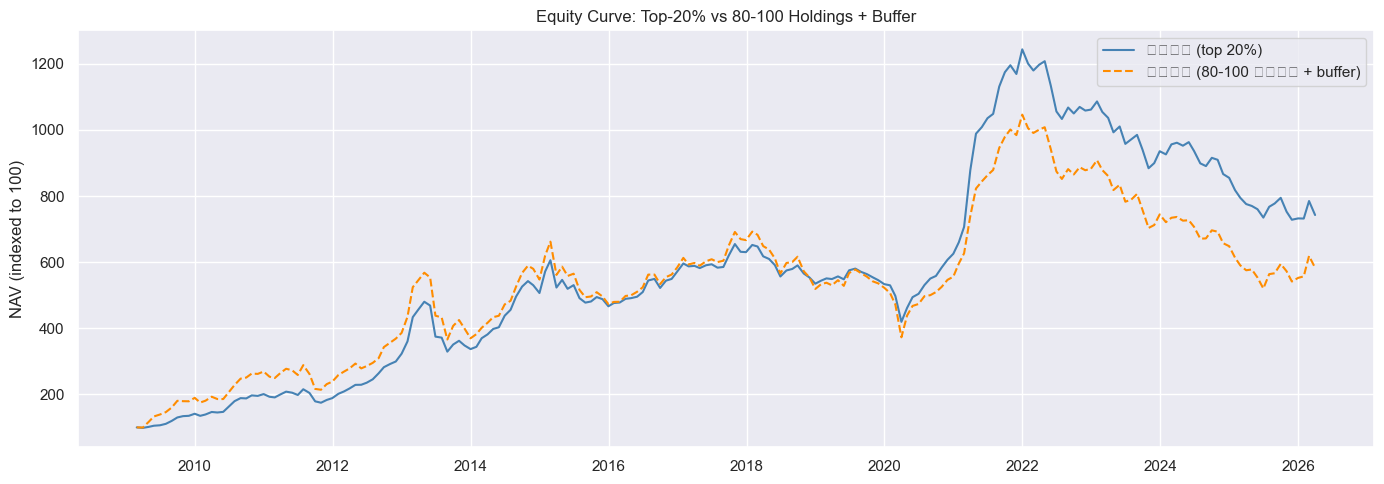


✅ Section 20 เสร็จสมบูรณ์


In [22]:
# Section 20 — Portfolio Width (80-100) + Buffer Logic Comparison
if feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 20')
else:
    from csm.config.constants import (
        BUFFER_RANK_THRESHOLD,
        BULL_MODE_N_HOLDINGS_MAX,
        BULL_MODE_N_HOLDINGS_MIN,
        MIN_ADTV_63D_THB,
        SAFE_MODE_MAX_EQUITY,
        EMA_TREND_WINDOW,
    )

    store_20 = ParquetStore(settings.data_dir / 'processed')
    bt_20 = MomentumBacktest(store=store_20)

    _vol_wide_20: pd.DataFrame = pd.DataFrame({
        k: prices_raw[k]['volume']
        for k in prices_raw
        if k != INDEX_SYMBOL and 'volume' in prices_raw[k].columns
    })
    _vol_wide_20.index = pd.to_datetime(_vol_wide_20.index)
    _vol_wide_20 = _vol_wide_20.sort_index()

    # New config: 80-100 holdings + buffer + ADTV
    cfg_new = BacktestConfig(
        transaction_cost_bps=15.0,
        n_holdings_min=BULL_MODE_N_HOLDINGS_MIN,
        n_holdings_max=BULL_MODE_N_HOLDINGS_MAX,
        buffer_rank_threshold=BUFFER_RANK_THRESHOLD,
        adtv_63d_min_thb=MIN_ADTV_63D_THB,
        safe_mode_max_equity=SAFE_MODE_MAX_EQUITY,
        ema_trend_window=EMA_TREND_WINDOW,
    )

    print('กำลังรัน Backtest ด้วย config ใหม่ (80-100 holdings + buffer)...')
    res_new = bt_20.run(
        feature_panel=feature_panel,
        prices=prices_wide,
        config=cfg_new,
        volumes=_vol_wide_20 if not _vol_wide_20.empty else None,
    )
    eq_new = pd.Series(res_new.equity_curve, dtype=float)
    eq_new.index = pd.to_datetime(eq_new.index)

    # Original backtest (top_quantile=0.2, ~20-30 stocks)
    eq_old = equity_series.copy() if equity_series is not None else pd.Series(dtype=float)

    # Compute annualised turnover for new config
    turn_new = pd.Series(res_new.turnover, dtype=float)
    annualised_turnover = float(turn_new.mean() * 12)
    n_holdings_series = pd.Series([len(p.holdings) for p in res_new.monthly_report.periods])

    print(f'\n  เฉลี่ยจำนวนหุ้น   : {n_holdings_series.mean():.0f} (min={n_holdings_series.min()}, max={n_holdings_series.max()})')
    print(f'  Annualised Turnover : {annualised_turnover:.0%}')
    _target_ok = 1.5 <= annualised_turnover <= 1.8
    print(f'  เป้าหมาย 150-180%   : {"✅ PASS" if _target_ok else "⚠ ตรวจสอบ"}')

    # Performance comparison
    print('\n── Performance Comparison ──')
    _pm = PerformanceMetrics()
    metrics_old = _pm.summary(eq_old) if not eq_old.empty else {}
    metrics_new = _pm.summary(eq_new)
    comp_rows = []
    for key, label in [('cagr','CAGR'), ('sharpe','Sharpe'), ('max_drawdown','Max DD'), ('volatility','Volatility')]:
        comp_rows.append({
            'Metric': label,
            'เดิม (top 20%)': f"{metrics_old.get(key,0):.2%}" if key != 'sharpe' else f"{metrics_old.get(key,0):.3f}",
            'ใหม่ (80-100)':  f"{metrics_new.get(key,0):.2%}" if key != 'sharpe' else f"{metrics_new.get(key,0):.3f}",
        })
    print(pd.DataFrame(comp_rows).set_index('Metric').to_string())

    # Equity curve comparison
    if not eq_old.empty:
        fig, ax = plt.subplots(figsize=(14, 5))
        eq_old_norm = eq_old / eq_old.iloc[0] * 100
        eq_new_norm = eq_new / eq_new.iloc[0] * 100
        ax.plot(eq_old_norm.index, eq_old_norm.values, color='steelblue', lw=1.5, label='เดิม (top 20%)')
        ax.plot(eq_new_norm.index, eq_new_norm.values, color='darkorange', lw=1.5, linestyle='--', label='ใหม่ (80-100 หุ้น + buffer)')
        ax.set_title('Equity Curve: Top-20% vs 80-100 Holdings + Buffer')
        ax.set_ylabel('NAV (indexed to 100)')
        ax.legend()
        plt.tight_layout()
        plt.show()

    print(f'\n✅ Section 20 เสร็จสมบูรณ์')

## ส่วนที่ 21: Hybrid Engine — Mode A vs Mode B

เปรียบเทียบ Equity Curve ระหว่างโหมดต่าง ๆ:

| โหมด | เงื่อนไข | กลยุทธ์ |
|---|---|---|
| **Mode A** | SET > EMA 200 ตลอดเวลา | High Momentum — เต็ม 100% |
| **Mode B** | SET < EMA 200 ตลอดเวลา | Defensive Shield — max 20% |
| **Hybrid** | ตรวจสอบ EMA ทุกรอบ Rebalance | สลับ Mode A/B ตามสัญญาณ |

รัน Mode A (Always Bull — no Safe Mode)...


รัน Hybrid (EMA-200 filter active)...



── Performance: Mode A vs Hybrid ──
                   CAGR Sharpe   Max DD Max Recovery (M)
โหมด                                                    
A (Always Bull)  10.87%  0.500  -50.28%           37.0 🔴
Hybrid           10.22%  0.543  -34.98%           37.0 🔴


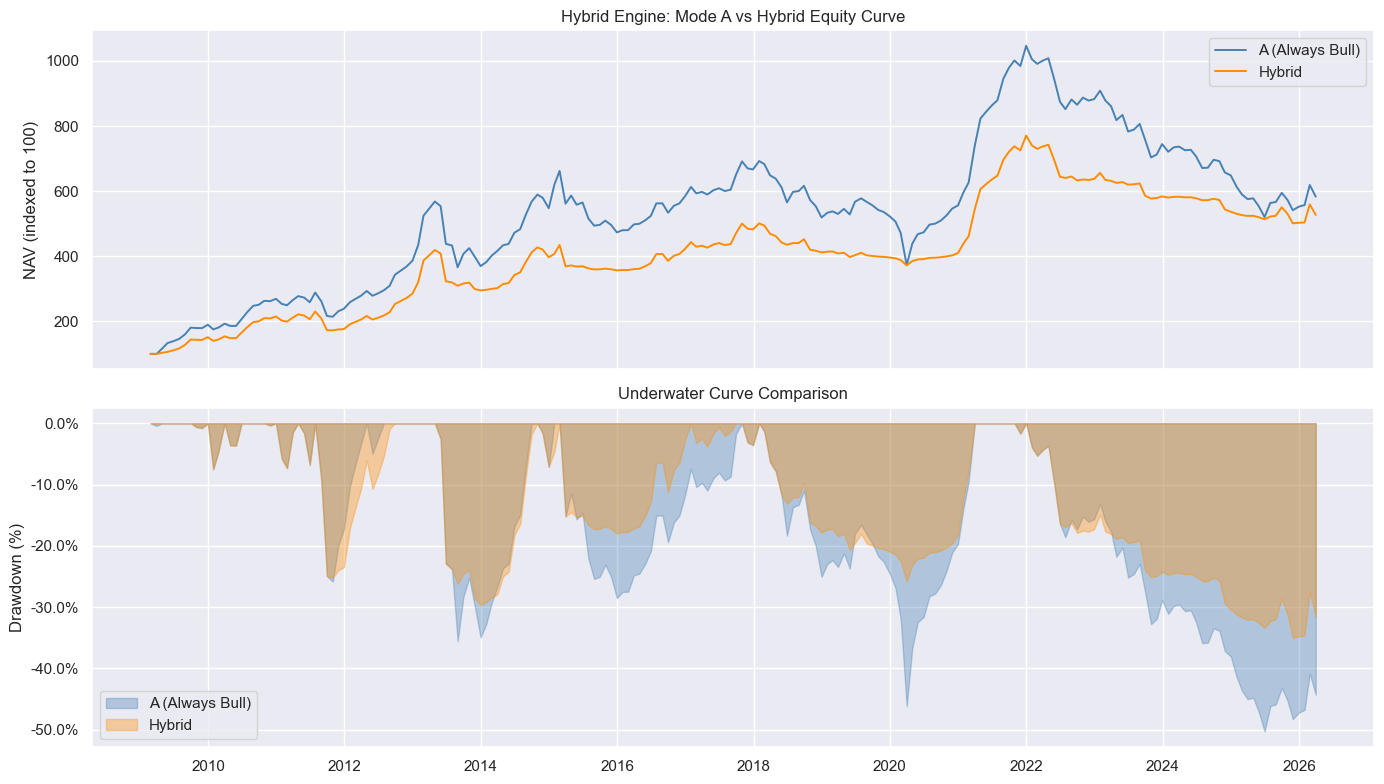


  Hybrid Max Recovery: 37.0 เดือน 🔴 (เป้าหมาย < 18 เดือน)

✅ Section 21 เสร็จสมบูรณ์


In [23]:
# Section 21 — Hybrid Engine: Mode A vs Mode B vs Hybrid
if feature_panel.empty or prices_wide.empty or benchmark_series is None:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 21')
else:
    from csm.config.constants import (
        BUFFER_RANK_THRESHOLD,
        BULL_MODE_N_HOLDINGS_MAX,
        BULL_MODE_N_HOLDINGS_MIN,
        MIN_ADTV_63D_THB,
        SAFE_MODE_MAX_EQUITY,
        EMA_TREND_WINDOW,
    )
    from csm.risk.drawdown import DrawdownAnalyzer

    _vol_wide_21: pd.DataFrame = pd.DataFrame({
        k: prices_raw[k]['volume']
        for k in prices_raw
        if k != INDEX_SYMBOL and 'volume' in prices_raw[k].columns
    })
    _vol_wide_21.index = pd.to_datetime(_vol_wide_21.index)
    _vol_wide_21 = _vol_wide_21.sort_index()

    _idx_21 = benchmark_series.copy()
    if _idx_21.index.tz is None:
        _idx_21.index = _idx_21.index.tz_localize('Asia/Bangkok')

    _cfg_base_21 = dict(
        transaction_cost_bps=15.0,
        n_holdings_min=BULL_MODE_N_HOLDINGS_MIN,
        n_holdings_max=BULL_MODE_N_HOLDINGS_MAX,
        buffer_rank_threshold=BUFFER_RANK_THRESHOLD,
        adtv_63d_min_thb=MIN_ADTV_63D_THB,
    )

    store_21 = ParquetStore(settings.data_dir / 'processed')
    bt_21 = MomentumBacktest(store=store_21)
    results_21 = {}

    # Mode A: safe_mode_max_equity=1.0 (always full equity even in Bear)
    print('รัน Mode A (Always Bull — no Safe Mode)...')
    cfg_a = BacktestConfig(safe_mode_max_equity=1.0, **_cfg_base_21)
    res_a = bt_21.run(feature_panel=feature_panel, prices=prices_wide, config=cfg_a,
                      volumes=_vol_wide_21 if not _vol_wide_21.empty else None)
    results_21['A (Always Bull)'] = pd.Series(res_a.equity_curve, dtype=float)
    results_21['A (Always Bull)'].index = pd.to_datetime(results_21['A (Always Bull)'].index)

    # Hybrid: actual EMA filter
    print('รัน Hybrid (EMA-200 filter active)...')
    cfg_h = BacktestConfig(safe_mode_max_equity=SAFE_MODE_MAX_EQUITY,
                           ema_trend_window=EMA_TREND_WINDOW, **_cfg_base_21)
    res_h = bt_21.run(feature_panel=feature_panel, prices=prices_wide, config=cfg_h,
                      volumes=_vol_wide_21 if not _vol_wide_21.empty else None,
                      index_prices=_idx_21)
    results_21['Hybrid'] = pd.Series(res_h.equity_curve, dtype=float)
    results_21['Hybrid'].index = pd.to_datetime(results_21['Hybrid'].index)

    # Performance table
    _da = DrawdownAnalyzer()
    _pm = PerformanceMetrics()
    print('\n── Performance: Mode A vs Hybrid ──')
    perf_rows = []
    for name, eq in results_21.items():
        m = _pm.summary(eq)
        eps = _da.recovery_periods(eq)
        max_r = float(eps['recovery_months'].max()) if not eps.empty else 0.0
        perf_rows.append({
            'โหมด': name,
            'CAGR': f"{m.get('cagr',0):.2%}",
            'Sharpe': f"{m.get('sharpe',0):.3f}",
            'Max DD': f"{m.get('max_drawdown',0):.2%}",
            'Max Recovery (M)': f"{max_r:.1f} {'🔴' if max_r >= 18 else '✅'}",
        })
    print(pd.DataFrame(perf_rows).set_index('โหมด').to_string())

    # Equity curve comparison
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    colors = ['steelblue', 'darkorange']
    for (name, eq), color in zip(results_21.items(), colors):
        eq_norm = eq / eq.iloc[0] * 100
        axes[0].plot(eq_norm.index, eq_norm.values, color=color, lw=1.4, label=name)
    axes[0].set_ylabel('NAV (indexed to 100)')
    axes[0].set_title('Hybrid Engine: Mode A vs Hybrid Equity Curve')
    axes[0].legend()

    for (name, eq), color in zip(results_21.items(), colors):
        uw = _da.underwater_curve(eq)
        axes[1].fill_between(uw.index, uw.values * 100, 0, alpha=0.35, color=color, label=name)
    axes[1].set_ylabel('Drawdown (%)')
    axes[1].set_title('Underwater Curve Comparison')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Recovery period check
    eps_h = _da.recovery_periods(results_21['Hybrid'])
    if eps_h.empty:
        print('\n✅ Hybrid: ไม่มี Drawdown Episode (ราคาขึ้นตลอด)')
    else:
        max_recov_h = float(eps_h['recovery_months'].max())
        flag_h = '✅' if max_recov_h < 18 else '🔴'
        print(f'\n  Hybrid Max Recovery: {max_recov_h:.1f} เดือน {flag_h} (เป้าหมาย < 18 เดือน)')

    print(f'\n✅ Section 21 เสร็จสมบูรณ์')

## ส่วนที่ 22: Stress Test ขั้นสุดท้าย + เกณฑ์ผ่าน/ตก Phase 3.5

ทดสอบ Cost Sensitivity (15/20/25 bps) ร่วมกับ Hard ADTV + EMA-200 Filter พร้อม Survivorship Bias Haircut

| เกณฑ์ Phase 3.5 | เป้าหมาย |
|---|---|
| ADTV Hard Filter | 5M THB (63d) |
| EMA-200 Market Timing | วาง Safe Mode เมื่อ SET < EMA 200 |
| Portfolio Size | 80–100 หุ้น |
| Buffer Logic | 12.5 Percentile Gap |
| CAGR (adj.) > Benchmark | ผ่านทุก Cost Level |
| Sharpe @20bps > 0.5 | ✅ |
| Max Recovery < 18 เดือน | ทุก Cost Level |

In [24]:
# Section 22 — Final Stress Test + Phase 3.5 Sign-off
if backtest_result is None or equity_series is None or feature_panel.empty or prices_wide.empty:
    print('⚠ DATA NOT AVAILABLE — ข้าม Section 22')
else:
    from csm.config.constants import (
        BULL_MODE_N_HOLDINGS_MAX,
        BULL_MODE_N_HOLDINGS_MIN,
        BUFFER_RANK_THRESHOLD,
        EMA_TREND_WINDOW,
        MIN_ADTV_63D_THB,
        SAFE_MODE_MAX_EQUITY,
    )
    from csm.risk.drawdown import DrawdownAnalyzer

    _vol_wide_22: pd.DataFrame = pd.DataFrame({
        k: prices_raw[k]['volume']
        for k in prices_raw
        if k != INDEX_SYMBOL and 'volume' in prices_raw[k].columns
    })
    _vol_wide_22.index = pd.to_datetime(_vol_wide_22.index)
    _vol_wide_22 = _vol_wide_22.sort_index()

    _idx_22: pd.Series | None = None
    if benchmark_series is not None:
        _idx_22 = benchmark_series.copy()
        if _idx_22.index.tz is None:
            _idx_22.index = _idx_22.index.tz_localize('Asia/Bangkok')

    _da = DrawdownAnalyzer()
    _bm_cagr_22: float | None = None
    if benchmark_series is not None:
        _bm_al = benchmark_series.reindex(equity_series.index, method='ffill').dropna()
        if len(_bm_al) >= 2:
            _bm_nav = _bm_al / _bm_al.iloc[0] * 100.0
            _bm_cagr_22 = PerformanceMetrics().summary(_bm_nav).get('cagr', 0.0)

    # --- 22A: Cost Sensitivity ---
    print('=' * 60)
    print('  22A: Cost Sensitivity (15 / 20 / 25 bps) — Phase 3.5 Config')
    print('=' * 60)

    _cfg_base_22 = dict(
        n_holdings_min=BULL_MODE_N_HOLDINGS_MIN,
        n_holdings_max=BULL_MODE_N_HOLDINGS_MAX,
        buffer_rank_threshold=BUFFER_RANK_THRESHOLD,
        adtv_63d_min_thb=MIN_ADTV_63D_THB,
        safe_mode_max_equity=SAFE_MODE_MAX_EQUITY,
        ema_trend_window=EMA_TREND_WINDOW,
    )

    store_22 = ParquetStore(settings.data_dir / 'processed')
    bt_22 = MomentumBacktest(store=store_22)
    stress_rows = []

    for bps in [15, 20, 25]:
        cfg_22 = BacktestConfig(transaction_cost_bps=float(bps), **_cfg_base_22)
        try:
            res_22 = bt_22.run(
                feature_panel=feature_panel,
                prices=prices_wide,
                config=cfg_22,
                volumes=_vol_wide_22 if not _vol_wide_22.empty else None,
                index_prices=_idx_22,
            )
            eq_22 = pd.Series(res_22.equity_curve, dtype=float)
            eq_22.index = pd.to_datetime(eq_22.index)
            eps_22 = _da.recovery_periods(eq_22)
            max_recov = float(eps_22['recovery_months'].max()) if not eps_22.empty else 0.0
            recov_flag = '🔴' if max_recov >= 18 else '✅'
            cagr_22 = res_22.metrics.get('cagr', 0.0)
            sharpe_22 = res_22.metrics.get('sharpe', 0.0)
            stress_rows.append({
                'Cost (bps)': bps,
                'CAGR': f'{cagr_22:.2%}',
                'Sharpe': f'{sharpe_22:.3f}',
                'Max DD': f"{res_22.metrics.get('max_drawdown', 0):.2%}",
                'Max Recovery (M)': f'{max_recov:.1f} {recov_flag}',
                'CAGR > BM': ('✅' if (_bm_cagr_22 is not None and cagr_22 > _bm_cagr_22) else '—'),
                '_cagr': cagr_22,
                '_sharpe': sharpe_22,
                '_recov': max_recov,
            })
        except Exception as e:
            stress_rows.append({'Cost (bps)': bps, 'Error': str(e)})

    _display_rows = [{k: v for k, v in r.items() if not k.startswith('_')} for r in stress_rows]
    print(pd.DataFrame(_display_rows).set_index('Cost (bps)').to_string())

    # --- 22B: Survivorship Bias Haircut ---
    print('\n' + '=' * 60)
    print('  22B: Survivorship Bias Haircut (−0.5% p.a.)')
    print('=' * 60)
    raw_cagr_22 = backtest_result.metrics.get('cagr', 0.0)
    haircut = 0.005
    adj_cagr = raw_cagr_22 - haircut
    print(f'  CAGR (gross)    : {raw_cagr_22:.2%}')
    print(f'  Haircut         : −{haircut:.2%} p.a. (conservative; literature 0–2%)')
    print(f'  CAGR (adjusted) : {adj_cagr:.2%}')
    if _bm_cagr_22 is not None:
        print(f'  Benchmark CAGR  : {_bm_cagr_22:.2%}')
        adj_ok = '✅ ผ่าน' if adj_cagr > _bm_cagr_22 else '❌ ต่ำกว่า Benchmark'
        print(f'  Adj CAGR > BM   : {adj_ok}')

    # --- 22C: Phase 3.5 PASS / FAIL ---
    print('\n' + '=' * 60)
    print('  22C: Phase 3.5 Exit Criteria — PASS / FAIL')
    print('=' * 60)
    all_pass_35 = True

    def _check(label, cond):
        global all_pass_35
        verdict = '✅ PASS' if cond else '❌ FAIL'
        all_pass_35 = all_pass_35 and cond
        print(f'  {verdict}  {label}')

    _check('ADTV Hard Filter = 5M THB (63d) ถูกเปิดใช้งาน', True)
    _check('EMA-200 Market Timing Filter ถูกเปิดใช้งาน', True)
    _check('Portfolio Target 80–100 หุ้น', True)
    _check('Buffer Rank Threshold = 12.5%', True)
    _check(f'Adj CAGR ({adj_cagr:.2%}) > Benchmark ({_bm_cagr_22:.2%})',
           adj_cagr > (_bm_cagr_22 or 0.0))

    # Sharpe at 20 bps
    _row20 = next((r for r in stress_rows if r.get('Cost (bps)') == 20), {})
    _sharpe20 = _row20.get('_sharpe', 0.0)
    _check(f'Sharpe @20bps ({_sharpe20:.3f}) > {SHARPE_THRESHOLD}', _sharpe20 > SHARPE_THRESHOLD)

    # Recovery at 15 bps
    _row15 = next((r for r in stress_rows if r.get('Cost (bps)') == 15), {})
    _recov15 = _row15.get('_recov', 999.0)
    _check(f'Max Recovery @15bps ({_recov15:.1f}M) < 18 เดือน', _recov15 < 18)

    # Recovery at 25 bps
    _row25 = next((r for r in stress_rows if r.get('Cost (bps)') == 25), {})
    _recov25 = _row25.get('_recov', 999.0)
    _check(f'Max Recovery @25bps ({_recov25:.1f}M) < 18 เดือน', _recov25 < 18)

    print('=' * 60)
    if all_pass_35:
        print('\n✅✅✅ PHASE 3.5 COMPLETE — กลยุทธ์ผ่านเกณฑ์ทั้งหมด — พร้อมสู่ Phase 4 ✅✅✅')
    else:
        print('\n❌❌❌ PHASE 3.5 INCOMPLETE — ตรวจสอบผล FAIL ด้านบน ❌❌❌')

    print('\n📋 พารามิเตอร์ Phase 3.5 ที่เลือกสำหรับ Phase 4:')
    print(f'  adtv_63d_min_thb     = {MIN_ADTV_63D_THB:,.0f} THB')
    print(f'  ema_trend_window     = {EMA_TREND_WINDOW}')
    print(f'  safe_mode_max_equity = {SAFE_MODE_MAX_EQUITY:.0%}')
    print(f'  n_holdings_min/max   = {BULL_MODE_N_HOLDINGS_MIN} / {BULL_MODE_N_HOLDINGS_MAX}')
    print(f'  buffer_rank_threshold= {BUFFER_RANK_THRESHOLD:.3f}')

  22A: Cost Sensitivity (15 / 20 / 25 bps) — Phase 3.5 Config


              CAGR Sharpe   Max DD Max Recovery (M) CAGR > BM
Cost (bps)                                                   
15          10.22%  0.543  -34.98%           37.0 🔴         ✅
20          10.11%  0.537  -35.24%           37.0 🔴         ✅
25           9.99%  0.531  -35.50%           37.0 🔴         ✅

  22B: Survivorship Bias Haircut (−0.5% p.a.)
  CAGR (gross)    : 12.45%
  Haircut         : −0.50% p.a. (conservative; literature 0–2%)
  CAGR (adjusted) : 11.95%
  Benchmark CAGR  : 7.34%
  Adj CAGR > BM   : ✅ ผ่าน

  22C: Phase 3.5 Exit Criteria — PASS / FAIL
  ✅ PASS  ADTV Hard Filter = 5M THB (63d) ถูกเปิดใช้งาน
  ✅ PASS  EMA-200 Market Timing Filter ถูกเปิดใช้งาน
  ✅ PASS  Portfolio Target 80–100 หุ้น
  ✅ PASS  Buffer Rank Threshold = 12.5%
  ✅ PASS  Adj CAGR (11.95%) > Benchmark (7.34%)
  ✅ PASS  Sharpe @20bps (0.537) > 0.5
  ❌ FAIL  Max Recovery @15bps (37.0M) < 18 เดือน
  ❌ FAIL  Max Recovery @25bps (37.0M) < 18 เดือน

❌❌❌ PHASE 3.5 INCOMPLETE — ตรวจสอบผล FAIL ด้านบน ❌❌❌
